[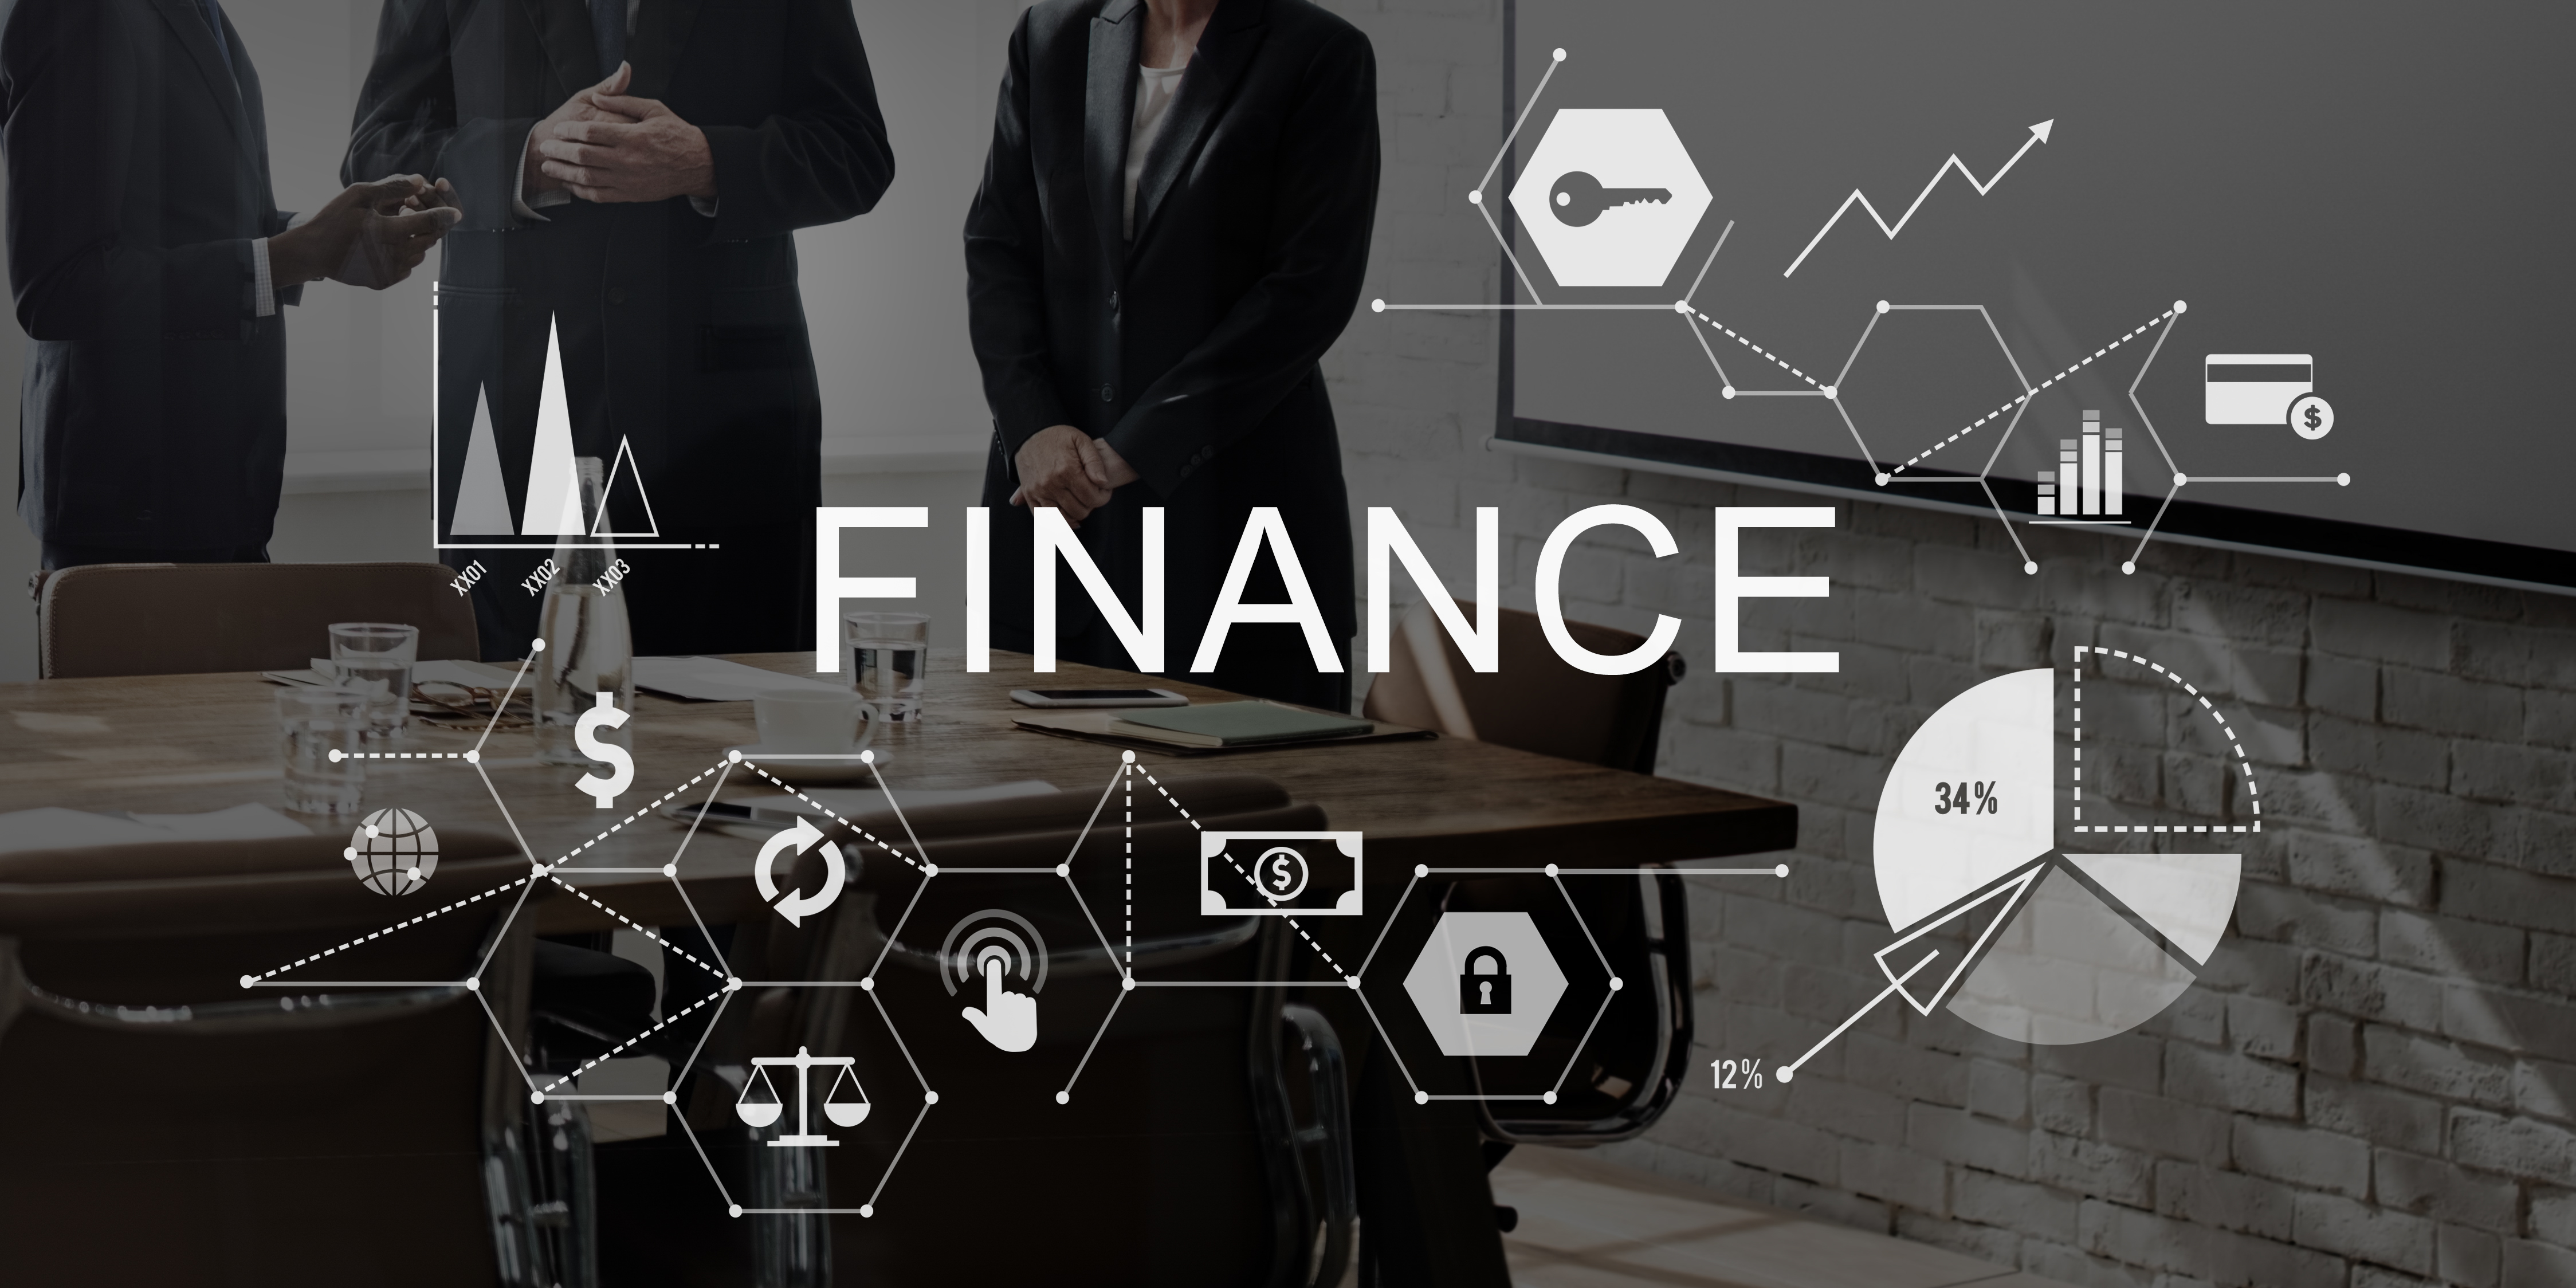]


# Title
-  Financial Loan Approval Risk Analysis

## Overview

Project Overview

In this project, I used the CRISP-DM framework to build a machine learning model for loan approval.

My main goal is to use past loan applications to predict whether an application was historically approved or not. I chose classification because LoanApproved is a binary target.I also used simple linear regression and multiple linear regression as my base models.

I will go through these main steps:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Conclusion and recommendations

The project brief gives two important business costs:

- False denial of a creditworthy applicant: $8,000
- False approval of a borrower who defaults: $50,000


### Main approach

I will compare eight classification models:

- simple linear regression(baseline model)
- multiple linear regresion(baseline model)
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- Support Vector Machine(svm)
- KNN

I will use a ColumnTransformer and Pipeline so that the preprocessing and modelling steps are kept together and applied consistently.

## Business Understanding



 1. Business problem

The current loan approval process depends heavily on manual review by loan officers. According to the project brief, this can make decisions slower and less consistent.A machine learning model can help with the first stage of screening. The final decision can still be reviewed by a loan officer.

2. Stakeholders

- Loan officers: They need useful and understandable predictions.
- Management:They want faster processing and lower financial losses.
- Customers:They need timely and consistent decisions.
- Risk and compliance team:they need a model that can be explained and monitored.
- Data and engineering team:They need a reproducible pipeline.

3. Cost of model errors

The project gives two different costs:
- A false denial can mean about $8,000 in lost profit.
- A false approval can mean about $50,000 in losses if the borrower defaults.

This means the two types of errors do not have the same cost.

For this project, I used:
Business cost = (False Positives * $50,000) + (False Negatives * $8000)

This is only an indirect measure because LoanApproved is the target and not actual default.

4.  Why I chose classification;

I used simple linear regression and multiple linear regression models as my baseline models but they are not the ideal models since I am working with binary as my target variable

I chose classification because LoanApproved contains two classes: 0 and 1.

Classification also allows me to use a confusion matrix, precision, recall, F1-score and ROC-AUC.

5. Success criteria

I will mainly look at:

- ROC-AUC: how well the model separates the two classes.
- Recall: how many positive approval cases are correctly identified.
- Precision: how many predicted approvals are actually approvals in the historical data.
- F1-score: balance between precision and recall.

These are my metrics targets:

- ROC-AUC ≥ 0.80
- Recall ≥ 0.90
- Precision ≥ 0.90



## Data Understanding

The project brief states that the dataset contains 20,000 historical loan applications and a mixture of numerical and categorical variables.

What I need to understand:

- Preview the dataset
- the size and structure of the data
- the data types
- the duplicates
- missing values
- the target distribution
- the distributions of important variables
- relationships between variables
- possible outliers and data quality problems




In [258]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_validate,
    GridSearchCV
)
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
%pip install xgboost
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier


import warnings
warnings.filterwarnings("ignore")


Note: you may need to restart the kernel to use updated packages.


In [259]:
#Load the dataset
df = pd.read_csv('financial_loan_data.csv')

In [260]:
# EDA Code Here - Create New Cells As Needed
# Previewing the dataset
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


I will have to clean AnnualIncome and restructure how the column names are named

In [261]:
#checking the size and structure of the data
df.shape

(20000, 35)

There are 20,000 rows and 35 columns

In [262]:
# Checking the data types and structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

The dataset contains numerical and categorical variables. AnnualIncome is stored as an object, even though income should be numerical.

In [263]:
# Checking for duplicate rows
df.duplicated().sum()

0

In [264]:
# Checking for the total missing values
df.isnull().sum().sum()

2804

In [265]:
# Checking missing values, sorted from highest to lowest
missing = df.isna().sum().sort_values(ascending=False)

missing

MaritalStatus                 1331
EducationLevel                 901
SavingsAccountBalance          572
Age                              0
JobTenure                        0
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
NetWorth                         0
PaymentHistory                   0
BaseInterestRate                 0
InterestRate                     0
MonthlyLoanPayment               0
TotalDebtToIncomeRatio           0
LoanApproved                     0
LengthOfCreditHistory            0
LoanPurpose                      0
PreviousLoanDefaults             0
AnnualIncome                     0
BankruptcyHistory                0
DebtToIncomeRatio                0
NumberOfCreditInquiries          0
NumberOfOpenCreditLines          0
CreditCardUtilizationRate        0
MonthlyDebtPayments              0
HomeOwnershipStatus              0
NumberOfDependents  

In [266]:
# Calculating the percentage of missing values
missing_pct = (missing / len(df) * 100).round(2)

missing_pct

MaritalStatus                 6.65
EducationLevel                4.50
SavingsAccountBalance         2.86
Age                           0.00
JobTenure                     0.00
CheckingAccountBalance        0.00
TotalAssets                   0.00
TotalLiabilities              0.00
MonthlyIncome                 0.00
UtilityBillsPaymentHistory    0.00
NetWorth                      0.00
PaymentHistory                0.00
BaseInterestRate              0.00
InterestRate                  0.00
MonthlyLoanPayment            0.00
TotalDebtToIncomeRatio        0.00
LoanApproved                  0.00
LengthOfCreditHistory         0.00
LoanPurpose                   0.00
PreviousLoanDefaults          0.00
AnnualIncome                  0.00
BankruptcyHistory             0.00
DebtToIncomeRatio             0.00
NumberOfCreditInquiries       0.00
NumberOfOpenCreditLines       0.00
CreditCardUtilizationRate     0.00
MonthlyDebtPayments           0.00
HomeOwnershipStatus           0.00
NumberOfDependents  

In [267]:
# Creating a table showing missing counts and percentages
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_table

,missing_count,missing_percent
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86
Age,0,0.00
JobTenure,0,0.00
CheckingAccountBalance,0,0.00
TotalAssets,0,0.00
TotalLiabilities,0,0.00
MonthlyIncome,0,0.00
UtilityBillsPaymentHistory,0,0.00


In [268]:
# Displaying only columns that have missing values
display(missing_table[missing_table["missing_count"] > 0])

,missing_count,missing_percent
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86


Marital status has the highest number of missing values of 1331 followed by educational level 901 then savings_account_balance with 572

In [269]:
# Checking the unique values of LoanApproved
df["LoanApproved"].unique()

array([0, 1], dtype=int64)

The target variable contains 0 and 1 ,this confirms that the main machine learning problem is a binary classification.

In [270]:
# Checking the distribution of the target variable
print("Target distribution:")

display(
    df["LoanApproved"]
    .value_counts()
    .rename_axis("LoanApproved")
    .to_frame("count")
)

Target distribution:


,count
LoanApproved,
0,15220
1,4780


In [271]:
# Checking the target distribution as percentages
display(
    (df["LoanApproved"].value_counts(normalize=True) * 100)
    .round(2)
    .rename_axis("LoanApproved")
    .to_frame("percent")
)

,percent
LoanApproved,
0,76.1
1,23.9


The dataset is imbalanced, with 0 (Not Approved) representing 76.1% of the observations and 1 (Approved) representing 23.9%.Because the classes are not equal, accuracy alone may give an incomplete picture of model performance.




In [272]:
# Rename columns to snake_case

df.columns = (
    df.columns
    .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
    .str.title()
)

print(df.columns.tolist())

['Age', 'Annual_Income', 'Credit_Score', 'Employment_Status', 'Education_Level', 'Experience', 'Loan_Amount', 'Loan_Duration', 'Marital_Status', 'Number_Of_Dependents', 'Home_Ownership_Status', 'Monthly_Debt_Payments', 'Credit_Card_Utilization_Rate', 'Number_Of_Open_Credit_Lines', 'Number_Of_Credit_Inquiries', 'Debt_To_Income_Ratio', 'Bankruptcy_History', 'Loan_Purpose', 'Previous_Loan_Defaults', 'Payment_History', 'Length_Of_Credit_History', 'Savings_Account_Balance', 'Checking_Account_Balance', 'Total_Assets', 'Total_Liabilities', 'Monthly_Income', 'Utility_Bills_Payment_History', 'Job_Tenure', 'Net_Worth', 'Base_Interest_Rate', 'Interest_Rate', 'Monthly_Loan_Payment', 'Total_Debt_To_Income_Ratio', 'Loan_Approved', 'Risk_Score']


In [273]:
# Checking the AnnualIncome column
df["Annual_Income"].head()

0     $39,948.00
1     $39,709.00
2     $40,724.00
3     $69,084.00
4    $103,264.00
Name: Annual_Income, dtype: object

In [274]:
# Clean AnnualIncome

df["Annual_Income"] = (
    df["Annual_Income"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Annual_Income"] = pd.to_numeric(
    df["Annual_Income"],
    errors="coerce"
)
print("Annual_Income data type:", df["Annual_Income"].dtype)
display(df["Annual_Income"].head())


Annual_Income data type: float64


0     39948.0
1     39709.0
2     40724.0
3     69084.0
4    103264.0
Name: Annual_Income, dtype: float64

I cleaned Annual_Income by removing the $ sign and commas and converting it to a numeric column.I did this during data understanding to enable me to visualize.

In [275]:
# Identifying numerical predictor variables
numeric_features = df.drop(columns=["Loan_Approved"]).select_dtypes(include=np.number).columns.tolist()

numeric_features

['Age',
 'Annual_Income',
 'Credit_Score',
 'Experience',
 'Loan_Amount',
 'Loan_Duration',
 'Number_Of_Dependents',
 'Monthly_Debt_Payments',
 'Credit_Card_Utilization_Rate',
 'Number_Of_Open_Credit_Lines',
 'Number_Of_Credit_Inquiries',
 'Debt_To_Income_Ratio',
 'Previous_Loan_Defaults',
 'Payment_History',
 'Length_Of_Credit_History',
 'Savings_Account_Balance',
 'Checking_Account_Balance',
 'Total_Assets',
 'Total_Liabilities',
 'Monthly_Income',
 'Utility_Bills_Payment_History',
 'Job_Tenure',
 'Net_Worth',
 'Base_Interest_Rate',
 'Interest_Rate',
 'Monthly_Loan_Payment',
 'Total_Debt_To_Income_Ratio',
 'Risk_Score']

In [276]:
# Checking the number of numerical features
print("Numerical features:", len(numeric_features))

Numerical features: 28


In [277]:
# Identifying categorical predictor variables
categorical_features= df.drop(columns=["Loan_Approved"]).select_dtypes(include="object").columns.tolist()

categorical_features

['Employment_Status',
 'Education_Level',
 'Marital_Status',
 'Home_Ownership_Status',
 'Bankruptcy_History',
 'Loan_Purpose']

In [278]:
# Checking the number of categorical features
print("Categorical features:", len(categorical_features))

Categorical features: 6


In [279]:
# Checking summary statistics
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
Annual_Income,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
Credit_Score,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
Employment_Status,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
Loan_Amount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
Loan_Duration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
Marital_Status,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_Of_Dependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


The data set has 6 categorical variable and 28 numerical variables

# Data understanding summary

I previewed the dataset, there are 20,000rows and 35 columns.There are zero duplicates and 2804 total missing values with marital status having the highest total number of missing values of 1331, followed by education level with 901 and finally with savings account balance with 572.I also checked for unique values under loan approved and their percentage distribution, where loan not approved have the highest percentage of 76.1% and loan aapproved having 23.9%.I separated the variables into numerical and categorical groups and looked at summary statistics.I also converted the  Annual_Income  from text to a number and also cleaned it before modelling .

# Feature understanding

The dataset contains numerical financial variables and categorical applicant information.

Some examples of numerical variables are:
The dataset has 28 numerical variables

- Age
- AnnualIncome
- CreditScore
- LoanAmount
- DebtToIncomeRatio
- MonthlyIncome
- RiskScore

Some categorical variables include:
The dataset has 6 categorical variables

- EmploymentStatus
- EducationLevel
- MaritalStatus
- HomeOwnershipStatus
- LoanPurpose

Annual_Income is stored as currency text, so I converted it to a numeric value.There are also 2804 missing values




### Exploratory visualizations

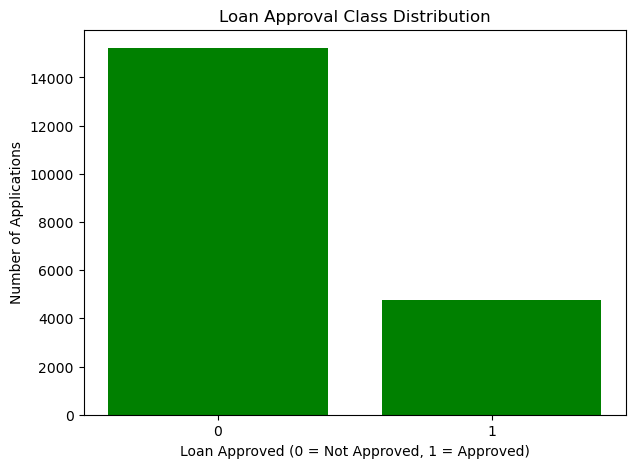

In [280]:
#  Target distribution

plt.figure(figsize=(7, 5))

# Counting approved and not approved applications
counts = df["Loan_Approved"].value_counts().sort_index()

# Creating the bar chart
plt.bar(counts.index.astype(str), counts.values, color="green")

# Adding labels and title
plt.title("Loan Approval Class Distribution")
plt.xlabel("Loan Approved (0 = Not Approved, 1 = Approved)")
plt.ylabel("Number of Applications")

plt.show()

This bar chart plots the number of approved and not_approved applications. The graph shows that the not approved group is much larger than the approved group. This confirms the class imbalance found in the percentage table.


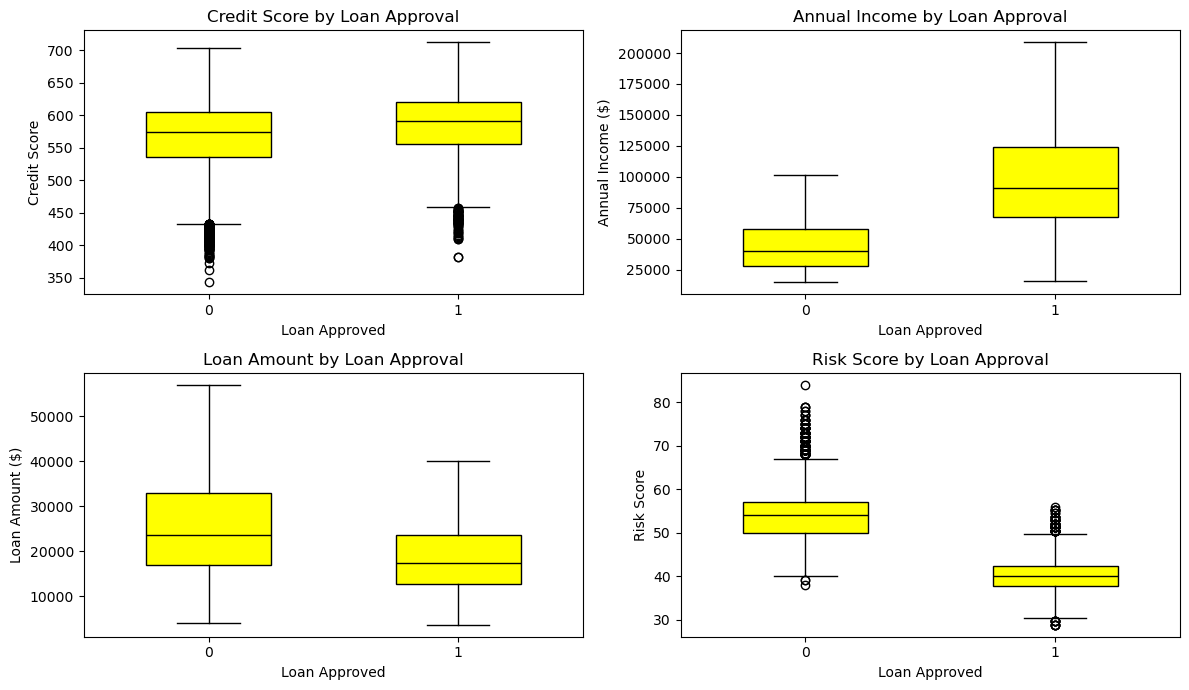

In [281]:
# Numerical variables by loan approval

plt.figure(figsize=(12, 7))

# 1. Credit Score
plt.subplot(2, 2, 1)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Credit_Score"],
    df.loc[df["Loan_Approved"] == 1, "Credit_Score"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor="yellow"),
    medianprops=dict(color="black")
)

plt.title("Credit Score by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")


# 2. Annual Income
plt.subplot(2, 2, 2)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Annual_Income"],
    df.loc[df["Loan_Approved"] == 1, "Annual_Income"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    widths=0.5,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="yellow"),
    medianprops=dict(color="black")
)

plt.title("Annual Income by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Annual Income ($)")


# 3. Loan Amount
plt.subplot(2, 2, 3)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Loan_Amount"],
    df.loc[df["Loan_Approved"] == 1, "Loan_Amount"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    widths=0.5,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="yellow"),
    medianprops=dict(color="black")
)

plt.title("Loan Amount by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Loan Amount ($)")


# 4. Risk Score
plt.subplot(2, 2, 4)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Risk_Score"],
    df.loc[df["Loan_Approved"] == 1, "Risk_Score"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor="yellow"),
    medianprops=dict(color="black")
)

plt.title("Risk Score by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Risk Score")


plt.tight_layout()
plt.show()

The boxplots compare approved and not approved applications across four numerical variables. The plots are intended to reveal differences in central tendency, spread and possible outliers between the two historical approval groups.

 The boxplots also help identify possible extreme values.Risk score by loan approval has outliers same to credit score by loan approval


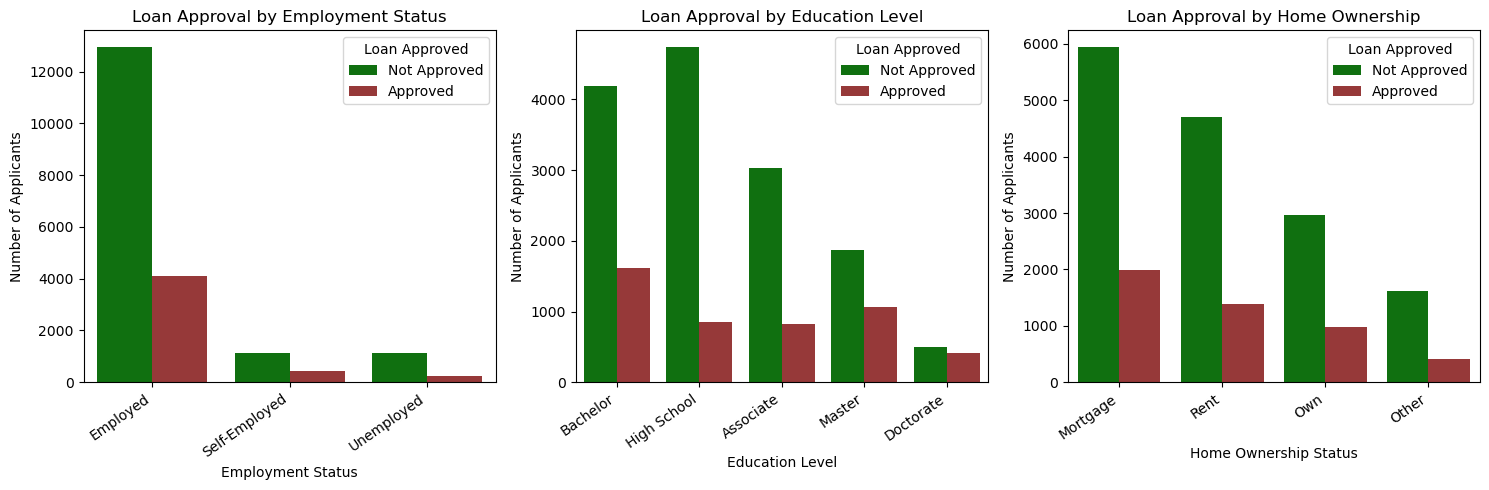

In [282]:

# Categorical variables by loan approval

plt.figure(figsize=(15, 5))

# 5. Employment Status
plt.subplot(1, 3, 1)

employment_order = df["Employment_Status"].value_counts().index

sns.countplot(
    x="Employment_Status",
    hue="Loan_Approved",
    data=df,
    order=employment_order,
    palette={0: "green", 1: "brown"}
)

plt.title("Loan Approval by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Loan Approved", labels=["Not Approved", "Approved"])


# 6. Education Level - descending order
plt.subplot(1, 3, 2)

education_order = df["Education_Level"].value_counts().index

sns.countplot(
    x="Education_Level",
    hue="Loan_Approved",
    data=df,
    order=education_order,
    palette={0: "green", 1: "brown"}
)

plt.title("Loan Approval by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Loan Approved", labels=["Not Approved", "Approved"])


# 7. Home Ownership Status
plt.subplot(1, 3, 3)

home_order = df["Home_Ownership_Status"].value_counts().index

sns.countplot(
    x="Home_Ownership_Status",
    hue="Loan_Approved",
    data=df,
    order=home_order,
    palette={0: "green", 1: "brown"}
)

plt.title("Loan Approval by Home Ownership")
plt.xlabel("Home Ownership Status")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Loan Approved", labels=["Not Approved", "Approved"])

plt.tight_layout()
plt.show()

This visualization examines categorical relationships with approval, including approval rate by loan purpose, and also prepares categorical comparisons alongside the numerical analysis. The purpose is to see whether approval rates vary across different categories categories.


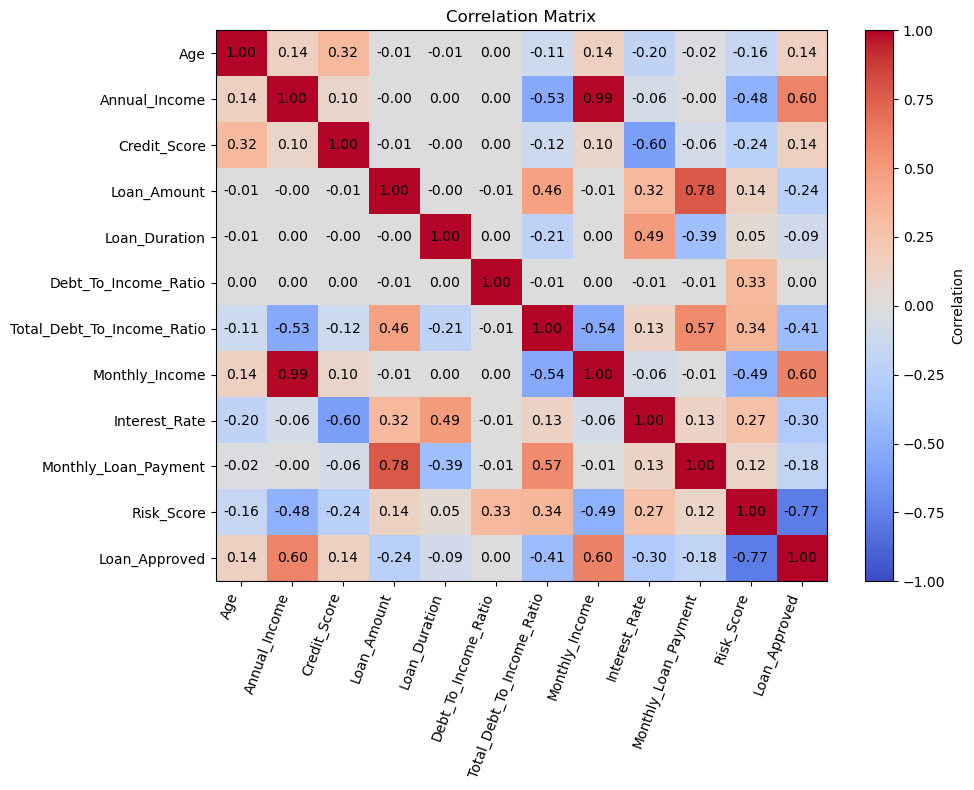

Correlation with Loan Approved:
Loan_Approved                 1.000000
Risk_Score                   -0.766137
Monthly_Income                0.604101
Annual_Income                 0.597900
Total_Debt_To_Income_Ratio   -0.410399
Interest_Rate                -0.301646
Loan_Amount                  -0.239496
Monthly_Loan_Payment         -0.184272
Credit_Score                  0.142000
Age                           0.141029
Loan_Duration                -0.094558
Debt_To_Income_Ratio          0.000034
Name: Loan_Approved, dtype: float64


In [284]:
# 7. Correlation Matrix

plt.figure(figsize=(10, 8))

corr_cols = [
    "Age", "Annual_Income", "Credit_Score", "Loan_Amount",
    "Loan_Duration", "Debt_To_Income_Ratio", "Total_Debt_To_Income_Ratio",
    "Monthly_Income", "Interest_Rate", "Monthly_Loan_Payment",
    "Risk_Score", "Loan_Approved"
]

corr_matrix = df[corr_cols].corr()

plt.imshow(
    corr_matrix,
    aspect="auto",
    interpolation="nearest",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=70,
    ha="right"
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

# Add correlation values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# Correlation with Loan Approved
loan_approval_corr = corr_matrix["Loan_Approved"].sort_values(
    key=abs,
    ascending=False
)

print("Correlation with Loan Approved:")
print(loan_approval_corr.head(12))

The correlation matrix shows the direction and strength of linear relationships between selected numerical variables.I use this heatmap graph to identify variables that may contain similar information(highly corelated). This is useful when thinking about multicollinearity and feature engineering.risk_scoree(-0.766) is highly corelated by loan_appproved.montly_income and annual_income are highly correlated(0.99)

In [285]:
# Check VIF for numerical features

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [
    "Age", "Annual_Income", "Credit_Score", "Loan_Amount",
    "Loan_Duration", "Debt_To_Income_Ratio",
    "Total_Debt_To_Income_Ratio", "Monthly_Income",
    "Interest_Rate", "Monthly_Loan_Payment",
    "Risk_Score"
]

# Remove missing values
vif_data = df[vif_cols].dropna()

# Calculate VIF

vif_results = pd.DataFrame()

vif_results["Feature"] = vif_data.columns

vif_results["VIF"] = [
    variance_inflation_factor(vif_data.values, i)
    for i in range(vif_data.shape[1])
]

# Sort by VIF
vif_results = vif_results.sort_values(
    "VIF",
    ascending=False
)

display(vif_results)

,Feature,VIF
7,Monthly_Income,162.431419
1,Annual_Income,156.949926
10,Risk_Score,65.672144
2,Credit_Score,56.607360
8,Interest_Rate,50.708152
3,Loan_Amount,15.606538
0,Age,14.421552
9,Monthly_Loan_Payment,13.962868
4,Loan_Duration,12.997879
6,Total_Debt_To_Income_Ratio,6.144884


These variables have very high VIFs Monthly_Income , Annual_Income , Risk_Score , Credit_Score , Interest_Rate , Loan_Amount , Age , Monthly_Loan_Payment , Loan_Duration , Total_Debt_To_Income_Ratio  and  Debt_To_Income_Ratio.
proving that there is a high multicolinearity among them.

## Data leakage check

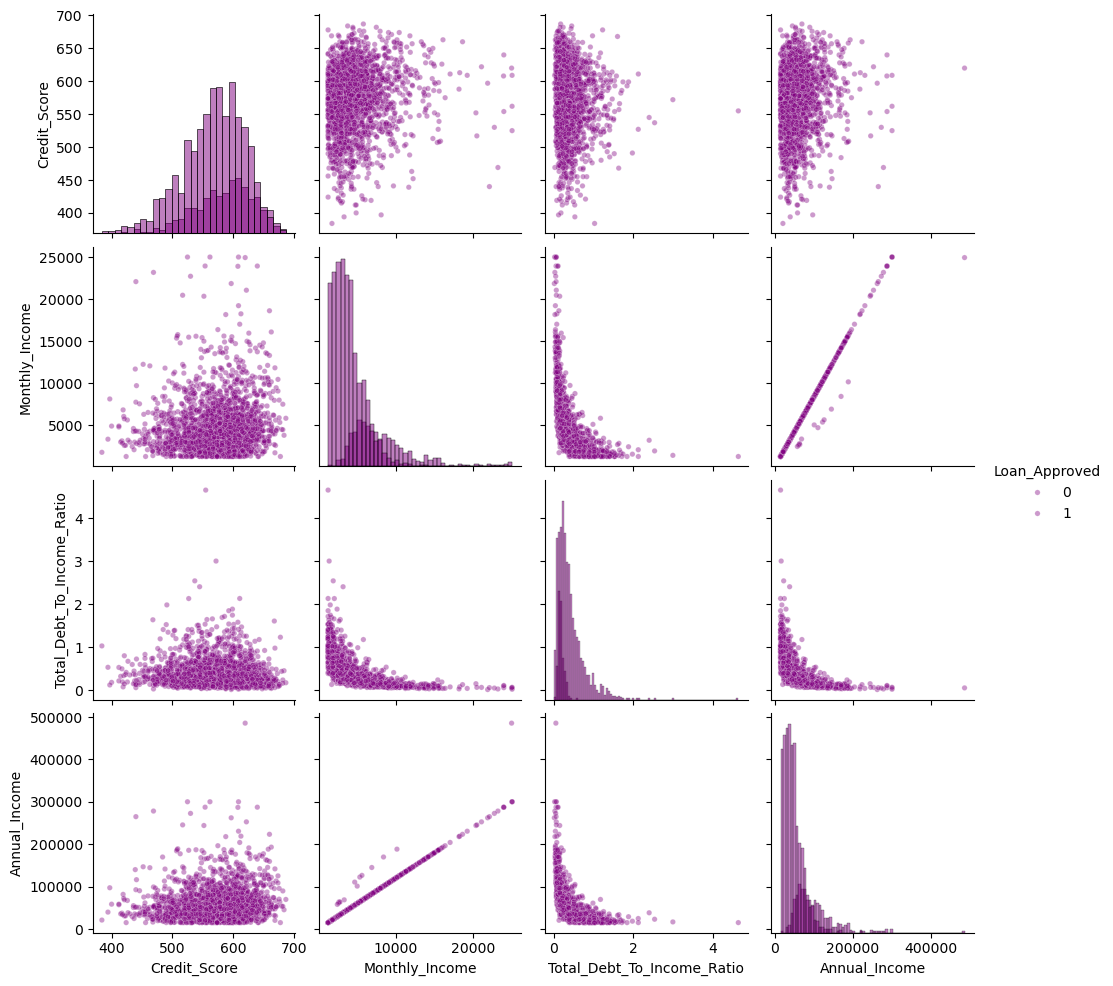

In [287]:
# Pair plot of a few genuinely predictive numerical features

pair_cols = [
    "Credit_Score",
    "Monthly_Income",
    "Total_Debt_To_Income_Ratio",
    "Annual_Income",
    "Loan_Approved"
]

pair_data = df[pair_cols].sample(2000, random_state=42)

sns.pairplot(
    pair_data,
    hue="Loan_Approved",
    diag_kind="hist",
    palette=["purple", "purple"],
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.show()

The pair plot shows relationships of several numerical variables against each other and against the target variable.

In [288]:
# Separate approved and not-approved loans

approved = df[df["Loan_Approved"] == 1]
not_approved = df[df["Loan_Approved"] == 0]

In [289]:
# T-test for numerical variables

approved = df[df["Loan_Approved"] == 1]
not_approved = df[df["Loan_Approved"] == 0]

test_rows = []

for col in [
    "Credit_Score",
    "Annual_Income",
    "Monthly_Income",
    "Total_Debt_To_Income_Ratio",
    "Loan_Amount"
]:

    approved_values = approved[col].dropna()
    not_approved_values = not_approved[col].dropna()

    stat, p = ttest_ind(
        approved_values,
        not_approved_values,
        equal_var=False
    )

    test_rows.append([col, stat, p])


In [290]:
# Display t-test results

ttest_results = pd.DataFrame(
    test_rows,
    columns=["feature", "t_statistic", "p_value"]
)

display(ttest_results)

,feature,t_statistic,p_value
0,Credit_Score,20.682430,1.080383e-92
1,Annual_Income,75.080252,0.000000e+00
2,Monthly_Income,76.458650,0.000000e+00
3,Total_Debt_To_Income_Ratio,-105.557507,0.000000e+00
4,Loan_Amount,-44.143602,0.000000e+00


The independent samples t-test shows that Annual_Income, Loan_Amount, Monthly_Income,Total_Debt_To_Income_Ratio , and Credit_Score have statistically significant differences between the loan approved and loan rejected groups, since their p-values are less than 0.05. This means that most of the financial and risk related variables appear to differ between the two loan approval groups. However, the t-test results alone do not mean that these variables will be good predictors, so I will further evaluate them  using the machine-learning models.

In [291]:
# Chi-square test for categorical variables

chi_rows = []

for col in [
    "Employment_Status",
    "Education_Level",
    "Home_Ownership_Status",
    "Loan_Purpose",
    "Marital_Status"
]:

    table = pd.crosstab(df[col], df["Loan_Approved"])

    chi2, p, dof, expected = chi2_contingency(table)

    chi_rows.append([col, chi2, p])



In [292]:
# Display chi-square results

chi_results = pd.DataFrame(
    chi_rows,
    columns=["feature", "chi2_statistic", "p_value"]
)

display(chi_results)

,feature,chi2_statistic,p_value
0,Employment_Status,38.506520,4.349261e-09
1,Education_Level,748.899523,8.976080e-161
2,Home_Ownership_Status,26.328828,8.138932e-06
3,Loan_Purpose,6.695746,1.528671e-01
4,Marital_Status,1.099775,7.771284e-01


The chi-square test shows that Employment_Status, Education_Level, and Home_Ownership Status have statistically significant relationships with loan approval because their p-values are below 0.05. Loan Purpose and Marital Status are not statistically significant because their p-values were above 0.05.

### Statistical test summary

The t-tests compare numerical variables between the two historical approval groups.The chi-square tests check whether selected categorical variables are associated with the approval target.These tests show statistical associations in the historical data. They do not prove causation.

### EDA observations

### CRISP-DM Summary: Data Understanding

I found:
- 20,000 observations and 35 columns.
- 0 duplicate rows.
- 2,804 total missing values.
- A binary target with about 76.1% not approved and 23.9% approved loans.
- 28 numerical predictors and 6 categorical predictors after cleaning Annual_Income.
- Differences in several financial variables between the two approval groups.
- Some categorical variables are associated with approval.
- Possible outliers and relationships between financial variables, especially the risk score and the credit score.

I cleaned Annual_Income .

## 3. Data Preparation



Steps I take during data preprocessing.

I will:
1. Separate X and y variables.
2. Create a few simple financial ratio features.
3. Split the data into training and test sets.
4. Build preprocessing pipelines.
5. Use ColumnTransformer so numerical and categorical variables are handled differently.

### Preprocessing choices
- Numerical missing values:
I will impute missing values with median because it is less affected by extreme financial values.

- Categorical missing values:
I will replace it with the most frequent value(mode).

- Categorical variables:
I will perform OneHotEncoder.

- Numerical variables:
I will perfom StandardScaler for the linear models.

- Tree models do not require scaling.

Preprocessing will be fitted inside the pipeline. This helps prevent data leakage during cross-validation.

In [293]:
# Data Prep Code Here - Create New Cells As Needed
# Data Prep Code Here - Create New Cells As Needed
# Separate the predictors and target

# Separate predictors (X) and target (y), dropping the target and the leaky columns
leaky_features = ["Risk_Score", "Interest_Rate", "Base_Interest_Rate", "Monthly_Loan_Payment"]

X = df.drop(columns=["Loan_Approved"] + leaky_features).copy()
y = df["Loan_Approved"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (20000, 30)
y shape: (20000,)


I used .copy to be able to perfom calculations without accidentally modifying my initial data set.I also dropped Risk_Score, Interest_Rate, Base_Interest_Rate, Monthly_Loan_Payment columns that are causing data leakage .

In [294]:
# Create simple financial ratio features

X["Loan_To_Annual_Income"] = (
    X["Loan_Amount"] / X["Annual_Income"].replace(0, np.nan)
)

X["Liability_To_Asset_Ratio"] = (
    X["Total_Liabilities"] / X["Total_Assets"].replace(0, np.nan)
)

X["Debt_To_Networth_Ratio"] = (
    X["Total_Liabilities"] / X["Net_Worth"].replace(0, np.nan)
)

print("New features created:")
print(["Loan_To_Annual_Income", "Liability_To_Asset_Ratio", "Debt_To_Networth_Ratio"])

New features created:
['Loan_To_Annual_Income', 'Liability_To_Asset_Ratio', 'Debt_To_Networth_Ratio']


I created three simple ratios describing the applicant's financial position relative to the loan being requested, none of which depend on the excluded leaky columns.

In [295]:
# Split into training and test data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 16000
Testing rows: 4000


I usde a 80/20 stratified split . Stratification keeps approximately the same approved and not approved proportions in both training and test data. The test set is kept separate until final evaluation.


In [296]:
# Build preprocessing pipelines

# Build preprocessing pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("Preprocessing pipeline created.")

Numeric columns: 27
Categorical columns: 6
Preprocessing pipeline created.


This step builds the main preprocessing architecture. Numerical variables go through median imputation and standardization, categorical variables go through imputation and one-hot encoding. Wrapping these steps in a ColumnTransformer and Pipeline keeps preprocessing consistent and reduces daata leakage risk.


In [297]:
# Set up cross-validation

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
print("5-fold stratified cross-validation ready.")


5-fold stratified cross-validation ready.


I use 5-fold stratified cross-validation so every model is tested on five different train/validation splits, keeping the same approval rate in each fold.

### Mean vs Median Imputation

I will compare mean and median imputation using the same Logistic Regression model and 5-fold stratified cross-validation.The purpose is to check whether the imputation choice changes ROC-AUC.

In [298]:
# Create a mean-imputation preprocessing pipeline

numeric_pipeline_mean = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline_mean = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_mean = ColumnTransformer([
    ("num", numeric_pipeline_mean, X_train.select_dtypes(include=np.number).columns.tolist()),
    ("cat", categorical_pipeline_mean, X_train.select_dtypes(include="object").columns.tolist())
])


# Create Logistic Regression pipelines

median_logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

mean_logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor_mean),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])


# Compare mean vs. median imputation using cross-validation

median_result = cross_validate(
    median_logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring="roc_auc"
)

mean_result = cross_validate(
    mean_logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring="roc_auc"
)


# Display results

print(
    "Median imputation mean ROC-AUC:",
    round(median_result["test_score"].mean(), 4)
)

print(
    "Mean imputation mean ROC-AUC:",
    round(mean_result["test_score"].mean(), 4)
)

Median imputation mean ROC-AUC: 0.9796
Mean imputation mean ROC-AUC: 0.9796


In [299]:
# Compare both approaches using 5-fold cross-validation

median_result = cross_validate(
    median_logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring="roc_auc",
    n_jobs=-1
)

mean_result = cross_validate(
    mean_logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring="roc_auc",
    n_jobs=-1
)

imputation_comparison = pd.DataFrame({
    "Imputation": ["Median", "Mean"],
    "Mean CV ROC-AUC": [
        median_result["test_score"].mean(),
        mean_result["test_score"].mean()
    ],
    "Std CV ROC-AUC": [
        median_result["test_score"].std(),
        mean_result["test_score"].std()
    ]
})

display(imputation_comparison.round(6))


,Imputation,Mean CV ROC-AUC,Std CV ROC-AUC
0,Median,0.979575,0.003437
1,Mean,0.979586,0.003420


I compared mean and median imputation using the same Logistic Regression model and 5-fold validation. Both approaches produced essentially identical mean ROC-AUC (0.9796) and standard deviation (0.0034). Because median imputation is less sensitive to extreme financial values, I kept median imputation as the main strategy.

### Preprocessing summary
# What I did:
- I separated X , y and leaky features (Risk_Score, Interest_Rate, Base_Interest_Rate, Monthly_Loan_Payment)
- I engineered three financial ratios
- I used an 80/20 stratified train-test split
- I created separate numerical and categorical pipelines
- I compared mean versus median imputation and established 5-fold stratified cross-validation.

# Outcome:
- The training set contains 16,000 records and the test set 4,000.
- Median and mean imputation performed essentially identically in cross-validation (both ROC-AUC = 0.976), so , I retained median imputation because it is less sensitive to extreme financial values.
- The preprocessing is embedded in the pipeline, which helps ensure that transformations are learned from the appropriate training folds.


I created separate pipelines for numerical and categorical variables I also compared median and mean imputation using 5-fold ,cross-validation. The main pipeline uses median imputation because it is less affected by extreme financial values.

### Preprocessing decision

I chose median imputation for the main numerical pipeline because financial data can contain extreme values.

For categorical variables, I use the most frequent value for missing data and One_HotEncoder(handle_unknown="ignore").

I use standardization because it is useful for Logistic Regression and puts numerical variables on a similar scale.

The preprocessing is inside the pipeline. This is important because the imputation, scaling and encoding should be learned from the training data during cross-validation and not from the full dataset.

## CRISP-DM Summary: Data Preparation

I prepared the data using ColumnTransformer and Pipeline.

Numerical variables are imputed and standardized. Categorical variables are imputed and one-hot encoded.

I also created three simple financial ratio features.

I kept the test set separate from model training and cross-validation.

## Modeling


### Modeling approach

I will do the models step by step.

First, I will use two regression models as classroom baselines:
- Simple Linear Regression
- Multiple Linear Regression

The target is binary, so these regression models are not the main solution. I use them only as simple baselines.

Then I will use classification models:
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- SVM
- KNN

For the classification models, I will compare ROC-AUC, accuracy, precision, recall and F1-score using 5-fold stratified cross-validation.

### Regression Baseline 1: Simple Linear Regression

I will start with Simple Linear Regression using Credit_Score as one predictor.This is only a baseline because Linear Regression produces continuous predictions, while Loan Approved is a binary target.

In [300]:
#  Modeling Code Here - Create New Cells as Needed
# Create the Simple Linear Regression model

simple_regression = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

# Create 5-fold cross-validation

simple_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [302]:
# Test the Simple Linear Regression model using 5-fold cross-validation

simple_result = cross_validate(
    simple_regression,
    X_train[["Credit_Score"]],
    y_train,
    cv=simple_cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

# Calculate the average scores

simple_mae = -simple_result["test_MAE"].mean()
simple_rmse = -simple_result["test_RMSE"].mean()
simple_r2 = simple_result["test_R2"].mean()

print("Simple Linear Regression")
print("Mean MAE:", round(simple_mae, 3))
print("Mean RMSE:", round(simple_rmse, 3))
print("Mean R2:", round(simple_r2, 3))

Simple Linear Regression
Mean MAE: 0.356
Mean RMSE: 0.422
Mean R2: 0.019


The simple linear regression baseline has mean MAE 0.356, RMSE 0.422 and R² 0.019. The very low R² means credit score alone explains only a small amount of variation in the binary approval target when treated as a continuous value.


In [303]:
# Fit the OLS model for the statistical summary

X_ols = sm.add_constant(X_train[["Credit_Score"]])

ols_simple = sm.OLS(y_train, X_ols).fit()

# Print the OLS summary

print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          Loan_Approved   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     330.3
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           4.49e-73
Time:                        17:21:23   Log-Likelihood:                -8904.2
No. Observations:               16000   AIC:                         1.781e+04
Df Residuals:                   15998   BIC:                         1.783e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4405      0.038    -11.735   

The OLS summary gives statistical details for the simple regression. R² is 0.019/0.020 , the credit-score coefficient is positive and statistically significant. However, this is still a linear approximation to a binary outcome.

### Regression Baseline 2: Multiple Linear Regression

I will  use several numerical predictors instead of only CreditScore.



In [304]:
# Select the numerical features

numeric_model_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_model_features)

Numerical features:
['Age', 'Annual_Income', 'Credit_Score', 'Experience', 'Loan_Amount', 'Loan_Duration', 'Number_Of_Dependents', 'Monthly_Debt_Payments', 'Credit_Card_Utilization_Rate', 'Number_Of_Open_Credit_Lines', 'Number_Of_Credit_Inquiries', 'Debt_To_Income_Ratio', 'Previous_Loan_Defaults', 'Payment_History', 'Length_Of_Credit_History', 'Savings_Account_Balance', 'Checking_Account_Balance', 'Total_Assets', 'Total_Liabilities', 'Monthly_Income', 'Utility_Bills_Payment_History', 'Job_Tenure', 'Net_Worth', 'Total_Debt_To_Income_Ratio', 'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio', 'Debt_To_Networth_Ratio']


In [305]:
# Create the Multiple Linear Regression model

multiple_regression = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [306]:
# Test the Multiple Linear Regression model using 5-fold cross-validation

multiple_result = cross_validate(
    multiple_regression,
    X_train[numeric_model_features],
    y_train,
    cv=simple_cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

# Calculate the average scores

multiple_mae = -multiple_result["test_MAE"].mean()
multiple_rmse = -multiple_result["test_RMSE"].mean()
multiple_r2 = multiple_result["test_R2"].mean()

print("Multiple Linear Regression")
print("Mean MAE:", round(multiple_mae, 3))
print("Mean RMSE:", round(multiple_rmse, 3))
print("Mean R2:", round(multiple_r2, 3))

Multiple Linear Regression
Mean MAE: 0.231
Mean RMSE: 0.3
Mean R2: 0.504


The multiple regression achieves mean MAE 0.231, RMSE 0.300 and R² 0.504 in 5-fold cross-validation. This is much stronger than the one-feature regression baseline, showing that the numerical predictors collectively contain substantial information about the historical approval target.


In [307]:
# Fit the OLS model for the statistical summary

X_ols = X_train[numeric_model_features].copy()

# Fill missing values with the median
X_ols = X_ols.fillna(X_ols.median())

# Add a constant for the intercept
X_ols = sm.add_constant(X_ols)

# Fit the OLS model
ols_multiple = sm.OLS(y_train, X_ols).fit()

# Print the OLS summary
print(ols_multiple.summary())

# Display R-squared
print("OLS R-squared:", round(ols_multiple.rsquared, 3))

                            OLS Regression Results                            
Dep. Variable:          Loan_Approved   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     608.1
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:21:36   Log-Likelihood:                -3411.6
No. Observations:               16000   AIC:                             6879.
Df Residuals:                   15972   BIC:                             7094.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

The OLS summary provides coefficient-level statistical information for the multiple numerical regression. Its R² is about 0.504/0.507, confirming the strong explanatory improvement over the simple regression. This is still a baseline because ordinary linear regression is not designed for a binary decision target.


### Regression Baseline Comparison

I will compare the two regression baselines separately from the classification models.

For regression:
- Lower MAE is better.
- Lower RMSE is better.
- Higher R2 is better.



In [308]:
# Compare the two regression baselines

regression_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "CV MAE": [
        simple_mae,
        multiple_mae
    ],
    "CV RMSE": [
        simple_rmse,
        multiple_rmse
    ],
    "CV R2": [
        simple_r2,
        multiple_r2
    ]
})

display(regression_comparison.round(3))

,Model,CV MAE,CV RMSE,CV R2
0,Simple Linear Regression,0.356,0.422,0.019
1,Multiple Linear Regression,0.231,0.300,0.504


Simple Linear Regression achieved  MAE = 0.356, RMSE = 0.422, R² = 0.019. Multiple Linear Regression improved to MAE = 0.231, RMSE = 0.300, R² = 0.504. This shows that the numerical predictors contain substantial information about the historical approval outcome, but regression is still an approximation because the target is binary.


### Classification models

### Classification Evaluation Setup

Every classification model will use the same preprocessing and the same 5-fold stratified cross-validation.

I will use:
- ROC-AUC
- Accuracy
- Precision
- Recall
- F1-score

In [309]:
# Define the classification evaluation metrics

classification_scoring = {
    "ROC-AUC": "roc_auc",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1"
}

print("Classification evaluation metrics are ready.")

Classification evaluation metrics are ready.


### Classification Model 1: Logistic Regression

Logistic Regression is the first main classification model. It is suitable for a binary target and is relatively easy to interpret.

In [310]:
# Create the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Create the complete pipeline

logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", logistic_model)
])

# Test the model using 5-fold stratified cross-validation

logistic_result = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Logistic Regression")
print("Mean ROC-AUC:", round(logistic_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(logistic_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(logistic_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(logistic_result["test_Recall"].mean(), 3))
print("Mean F1:", round(logistic_result["test_F1"].mean(), 3))

# Fit the model on the training data

logistic_pipeline.fit(X_train, y_train)

Logistic Regression
Mean ROC-AUC: 0.98
Mean Accuracy: 0.917
Mean Precision: 0.77
Mean Recall: 0.93
Mean F1: 0.842


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

I evaluated Logistic Regression  through the same 5-fold stratified cross-validation. Its mean ROC-AUC =0.98, accuracy = 0.917, precision = 0.77, recall = 0.93 and F1 = 0.842. It provides a strong and relatively interpretable classification baseline.


### Classification Model 2: Decision Tree

A Decision Tree learns decision rules from the data. It can model non-linear relationships and is easy to visualize.

In [311]:
# Create the Decision Tree model

decision_tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

# Create the complete pipeline

decision_tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", decision_tree)
])

# Test the model using 5-fold stratified cross-validation

decision_tree_result = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Decision Tree")
print("Mean ROC-AUC:", round(decision_tree_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(decision_tree_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(decision_tree_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(decision_tree_result["test_Recall"].mean(), 3))
print("Mean F1:", round(decision_tree_result["test_F1"].mean(), 3))

# Fit the model on the training data

decision_tree_pipeline.fit(X_train, y_train)

Decision Tree
Mean ROC-AUC: 0.935
Mean Accuracy: 0.847
Mean Precision: 0.627
Mean Recall: 0.896
Mean F1: 0.737


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

The Decision Tree produces mean ROC-AUC = 0.935, accuracy = 0.847, precision = 0.627, recall = 0.986 and F1 = 0.737. It captures non-linear rules and is interpretable through decision paths.


### Classification Model 3: Random Forest

Random Forest combines many decision trees. It can capture non-linear relationships and is useful for checking feature importance.

In [312]:
# Create the Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Create the complete pipeline

random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", random_forest)
])

# Test the model using 5-fold stratified cross-validation

random_forest_result = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Random Forest")
print("Mean ROC-AUC:", round(random_forest_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(random_forest_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(random_forest_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(random_forest_result["test_Recall"].mean(), 3))
print("Mean F1:", round(random_forest_result["test_F1"].mean(), 3))

# Fit the model on the training data

random_forest_pipeline.fit(X_train, y_train)

Random Forest
Mean ROC-AUC: 0.963
Mean Accuracy: 0.889
Mean Precision: 0.715
Mean Recall: 0.894
Mean F1: 0.794


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

The Random Forest produces mean ROC-AUC = 0.963, accuracy 0.889, precision= 0.715, recall = 0.894 and F1 =  0.794. It is an ensemble of trees and is useful because it can capture non-linear relationships while also providing feature-importance measures.


### Classification Model 4: AdaBoost

AdaBoost combines weak learners and gives more attention to observations that are harder to classify.

In [313]:
# Create the AdaBoost model

adaboost = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Create the complete pipeline

adaboost_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", adaboost)
])

# Test the model using 5-fold stratified cross-validation

adaboost_result = cross_validate(
    adaboost_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("AdaBoost")
print("Mean ROC-AUC:", round(adaboost_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(adaboost_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(adaboost_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(adaboost_result["test_Recall"].mean(), 3))
print("Mean F1:", round(adaboost_result["test_F1"].mean(), 3))

# Fit the model on the training data

adaboost_pipeline.fit(X_train, y_train)

AdaBoost
Mean ROC-AUC: 0.965
Mean Accuracy: 0.906
Mean Precision: 0.818
Mean Recall: 0.779
Mean F1: 0.798


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

AdaBoost produces mean ROC-AUC = 965, accuracy = 0.906, precision = 0.818, recall 0.779 and F1 =  0.798. 


### Classification Model 5: Gradient Boosting

Gradient Boosting builds trees step by step, with each new tree trying to improve the previous model.

In [314]:
# Create the Gradient Boosting model

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Create the complete pipeline

gradient_boosting_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", gradient_boosting)
])

# Test the model using 5-fold stratified cross-validation

gradient_boosting_result = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Gradient Boosting")
print("Mean ROC-AUC:", round(gradient_boosting_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(gradient_boosting_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(gradient_boosting_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(gradient_boosting_result["test_Recall"].mean(), 3))
print("Mean F1:", round(gradient_boosting_result["test_F1"].mean(), 3))

# Fit the model on the training data

gradient_boosting_pipeline.fit(X_train, y_train)

Gradient Boosting
Mean ROC-AUC: 0.966
Mean Accuracy: 0.913
Mean Precision: 0.845
Mean Recall: 0.779
Mean F1: 0.81


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

Gradient Boosting produces mean ROC-AUC = 0.996, accuracy = 0.913, precision = 0.845, recall = 0.779 and F1 = 0.81. 


### Classification Model 6: XGBoost

XGBoost is a boosting model that can learn complex non-linear relationships. I include it as an additional classification model for comparison.

In [315]:
# Create the XGBoost model

xgboost = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Create the complete pipeline

xgboost_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", xgboost)
])

# Test the model using 5-fold stratified cross-validation

xgboost_result = cross_validate(
    xgboost_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("XGBoost")
print("Mean ROC-AUC:", round(xgboost_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(xgboost_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(xgboost_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(xgboost_result["test_Recall"].mean(), 3))
print("Mean F1:", round(xgboost_result["test_F1"].mean(), 3))

# Fit the model on the training data

xgboost_pipeline.fit(X_train, y_train)

XGBoost
Mean ROC-AUC: 0.968
Mean Accuracy: 0.915
Mean Precision: 0.845
Mean Recall: 0.789
Mean F1: 0.816


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

XGBoost produces mean ROC-AUC = 0.968, accuracy = 0.915, precision  = 0.845, recall = 0.789 and F1 = 0.816. 

Classification Model 7: Support Vector Machine (SVM)

In [316]:
# Create the SVM model

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Create the complete pipeline

svm_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", svm)
])

# Test the model using 5-fold stratified cross-validation

svm_result = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Support Vector Machine")
print("Mean ROC-AUC:", round(svm_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(svm_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(svm_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(svm_result["test_Recall"].mean(), 3))
print("Mean F1:", round(svm_result["test_F1"].mean(), 3))

# Fit the model on the training data

svm_pipeline.fit(X_train, y_train)

Support Vector Machine
Mean ROC-AUC: 0.974
Mean Accuracy: 0.924
Mean Precision: 0.869
Mean Recall: 0.804
Mean F1: 0.835


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

The SVM with an RBF kernel produces mean ROC-AUC = 0.974, accuracy = 0.924, precision = 0.869, recall = 0.804 and F1 = 0.835.

Classification Model 8: K-Nearest Neighbors (KNN)

In [317]:
# Create the KNN model

knn = KNeighborsClassifier(
    n_neighbors=5
)

# Create the complete pipeline

knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", knn)
])

# Test the model using 5-fold stratified cross-validation

knn_result = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("K-Nearest Neighbors")
print("Mean ROC-AUC:", round(knn_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(knn_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(knn_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(knn_result["test_Recall"].mean(), 3))
print("Mean F1:", round(knn_result["test_F1"].mean(), 3))

# Fit the model on the training data

knn_pipeline.fit(X_train, y_train)

K-Nearest Neighbors
Mean ROC-AUC: 0.902
Mean Accuracy: 0.87
Mean Precision: 0.779
Mean Recall: 0.635
Mean F1: 0.7


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

KNN produces mean ROC-AUC = 0.902, accuracy = 0.87, precision = 0.779, recall = 0.635 and F1 = 0.7. Its recall is noticeably lower than the other classifiers, showing that it misses more of the positive approval class in cross-validation.


I compared multiple algorithms under the same preprocessing and 5-fold stratified validation procedure so  that the comparison would be consistent.

# Outcome:
# ROC-AUC values produced per model

I evaluated eight classifiers ;

- Logistic Regression = 0.98

-  AdaBoost = 0.96

- XGBoost = 0.968

- SVM = 0.974

- Random Forest = 0.963

- Gradient Boosting = 0.996

- Decision Tree  = 0.935

- KNN = 0.902.

- KNN  had the lowest recall (0.902). The results show that several approaches perform extremely strongly on this historical dataset.

### Classification Model Comparison



In [318]:
 # Store the classification results

model_results = [
    {
        "Model": "Logistic Regression",
        "CV ROC-AUC": logistic_result["test_ROC-AUC"].mean(),
        "CV Accuracy": logistic_result["test_Accuracy"].mean(),
        "CV Precision": logistic_result["test_Precision"].mean(),
        "CV Recall": logistic_result["test_Recall"].mean(),
        "CV F1": logistic_result["test_F1"].mean()
    },
    {
        "Model": "Decision Tree",
        "CV ROC-AUC": decision_tree_result["test_ROC-AUC"].mean(),
        "CV Accuracy": decision_tree_result["test_Accuracy"].mean(),
        "CV Precision": decision_tree_result["test_Precision"].mean(),
        "CV Recall": decision_tree_result["test_Recall"].mean(),
        "CV F1": decision_tree_result["test_F1"].mean()
    },
    {
        "Model": "Random Forest",
        "CV ROC-AUC": random_forest_result["test_ROC-AUC"].mean(),
        "CV Accuracy": random_forest_result["test_Accuracy"].mean(),
        "CV Precision": random_forest_result["test_Precision"].mean(),
        "CV Recall": random_forest_result["test_Recall"].mean(),
        "CV F1": random_forest_result["test_F1"].mean()
    },
    {
        "Model": "AdaBoost",
        "CV ROC-AUC": adaboost_result["test_ROC-AUC"].mean(),
        "CV Accuracy": adaboost_result["test_Accuracy"].mean(),
        "CV Precision": adaboost_result["test_Precision"].mean(),
        "CV Recall": adaboost_result["test_Recall"].mean(),
        "CV F1": adaboost_result["test_F1"].mean()
    },
    {
        "Model": "Gradient Boosting",
        "CV ROC-AUC": gradient_boosting_result["test_ROC-AUC"].mean(),
        "CV Accuracy": gradient_boosting_result["test_Accuracy"].mean(),
        "CV Precision": gradient_boosting_result["test_Precision"].mean(),
        "CV Recall": gradient_boosting_result["test_Recall"].mean(),
        "CV F1": gradient_boosting_result["test_F1"].mean()
    },
    {
        "Model": "XGBoost",
        "CV ROC-AUC": xgboost_result["test_ROC-AUC"].mean(),
        "CV Accuracy": xgboost_result["test_Accuracy"].mean(),
        "CV Precision": xgboost_result["test_Precision"].mean(),
        "CV Recall": xgboost_result["test_Recall"].mean(),
        "CV F1": xgboost_result["test_F1"].mean()
    },
    {
        "Model": "svm",
        "CV ROC-AUC": svm_result["test_ROC-AUC"].mean(),
        "CV Accuracy": svm_result["test_Accuracy"].mean(),
        "CV Precision": svm_result["test_Precision"].mean(),
        "CV Recall": svm_result["test_Recall"].mean(),
        "CV F1": svm_result["test_F1"].mean()
    },
    {
        "Model": "knn",
        "CV ROC-AUC": knn_result["test_ROC-AUC"].mean(),
        "CV Accuracy": knn_result["test_Accuracy"].mean(),
        "CV Precision": knn_result["test_Precision"].mean(),
        "CV Recall": knn_result["test_Recall"].mean(),
        "CV F1": knn_result["test_F1"].mean()
    },
]

model_comparison = pd.DataFrame(model_results)

display(model_comparison.round(3))

,Model,CV ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1
0,Logistic Regression,0.980,0.917,0.770,0.930,0.842
1,Decision Tree,0.935,0.847,0.627,0.896,0.737
2,Random Forest,0.963,0.889,0.715,0.894,0.794
3,AdaBoost,0.965,0.906,0.818,0.779,0.798
4,Gradient Boosting,0.966,0.913,0.845,0.779,0.810
5,XGBoost,0.968,0.915,0.845,0.789,0.816
6,svm,0.974,0.924,0.869,0.804,0.835
7,knn,0.902,0.870,0.779,0.635,0.700


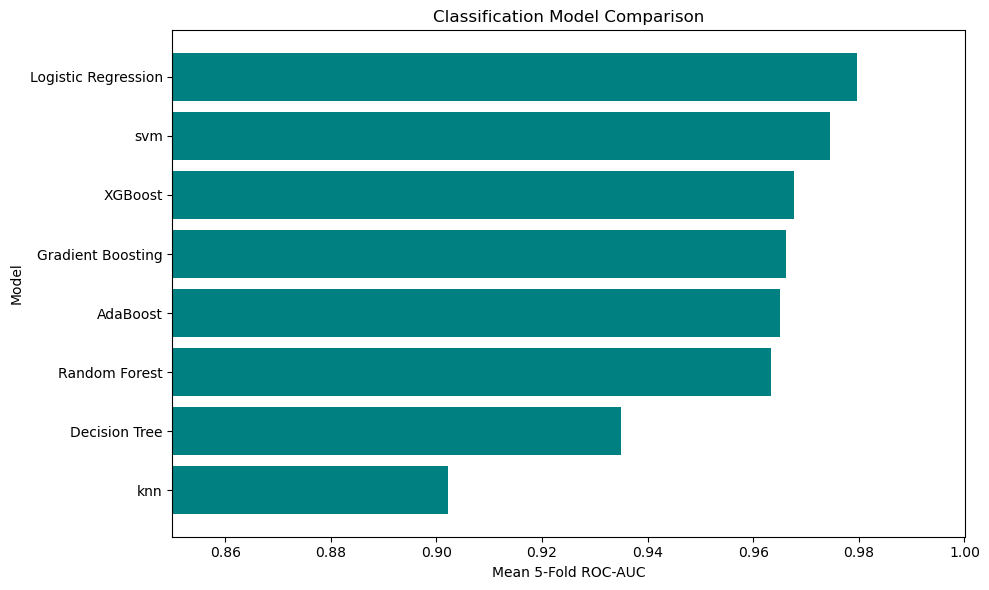

In [319]:
#  Classification model comparison

plot_df = model_comparison.sort_values("CV ROC-AUC")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["CV ROC-AUC"],
    color="teal"
)

plt.xlabel("Mean 5-Fold ROC-AUC")
plt.ylabel("Model")
plt.title("Classification Model Comparison")

plt.xlim(0.85, 1.0)

plt.tight_layout()
plt.show()

### Decision Tree Visualization



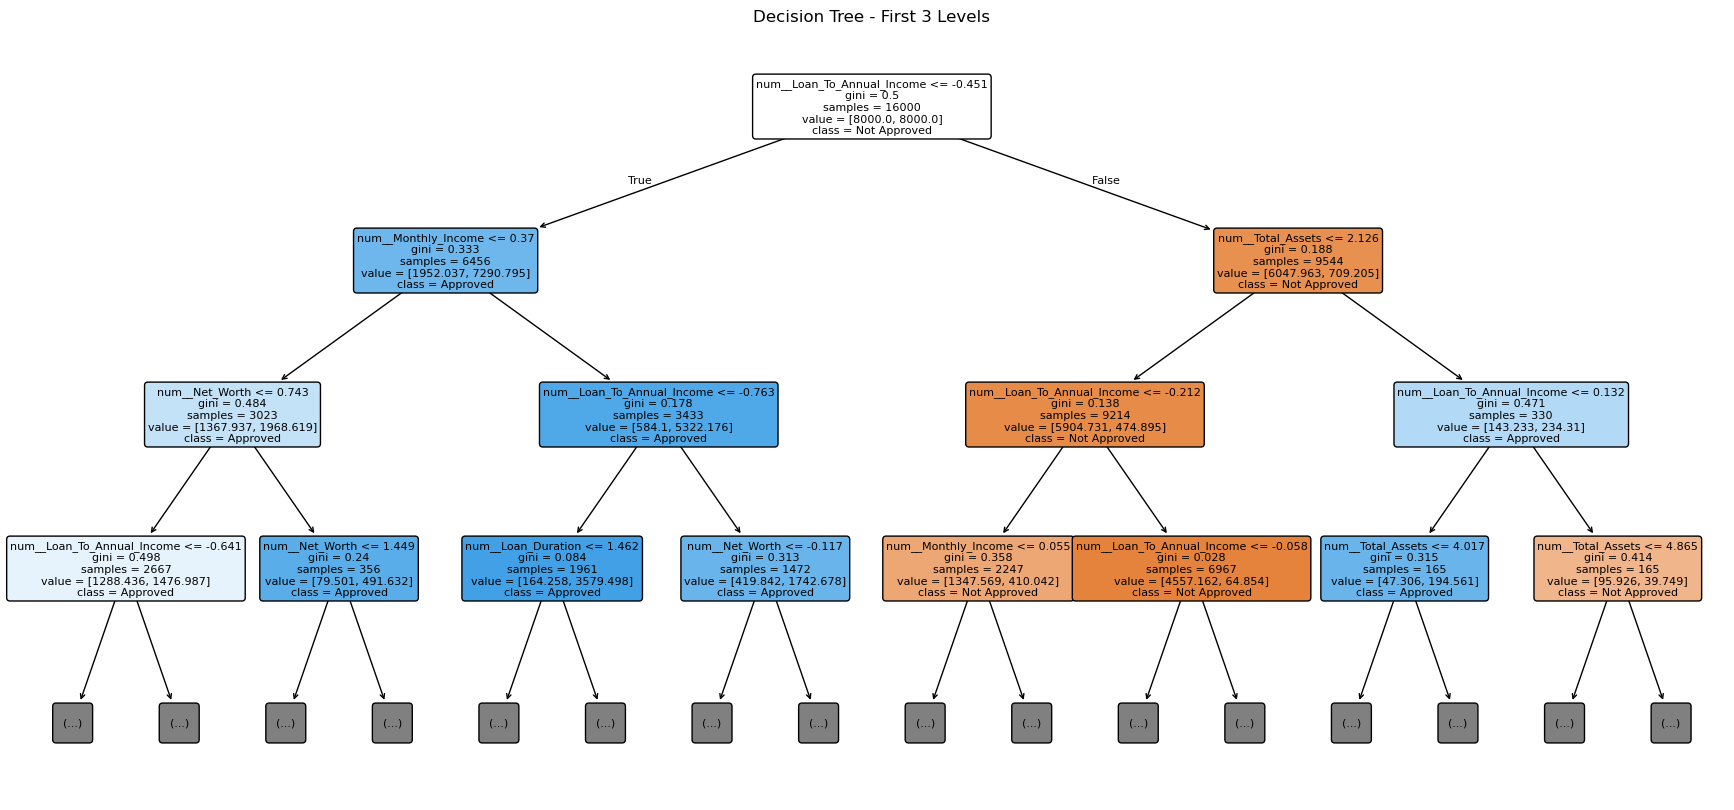

In [320]:
# Get the fitted preprocessing and tree model

tree_prep = decision_tree_pipeline.named_steps["preprocessing"]
tree_model = decision_tree_pipeline.named_steps["model"]

tree_feature_names = tree_prep.get_feature_names_out()

# Draw the Decision Tree

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree - First 3 Levels")
plt.show()

### Random Forest Visualization

A Random Forest contains many decision trees, so the whole forest cannot be shown clearly in one diagram.Instead, I will draw one tree from the fitted Random Forest to show an example of the decision rules used by the ensemble.

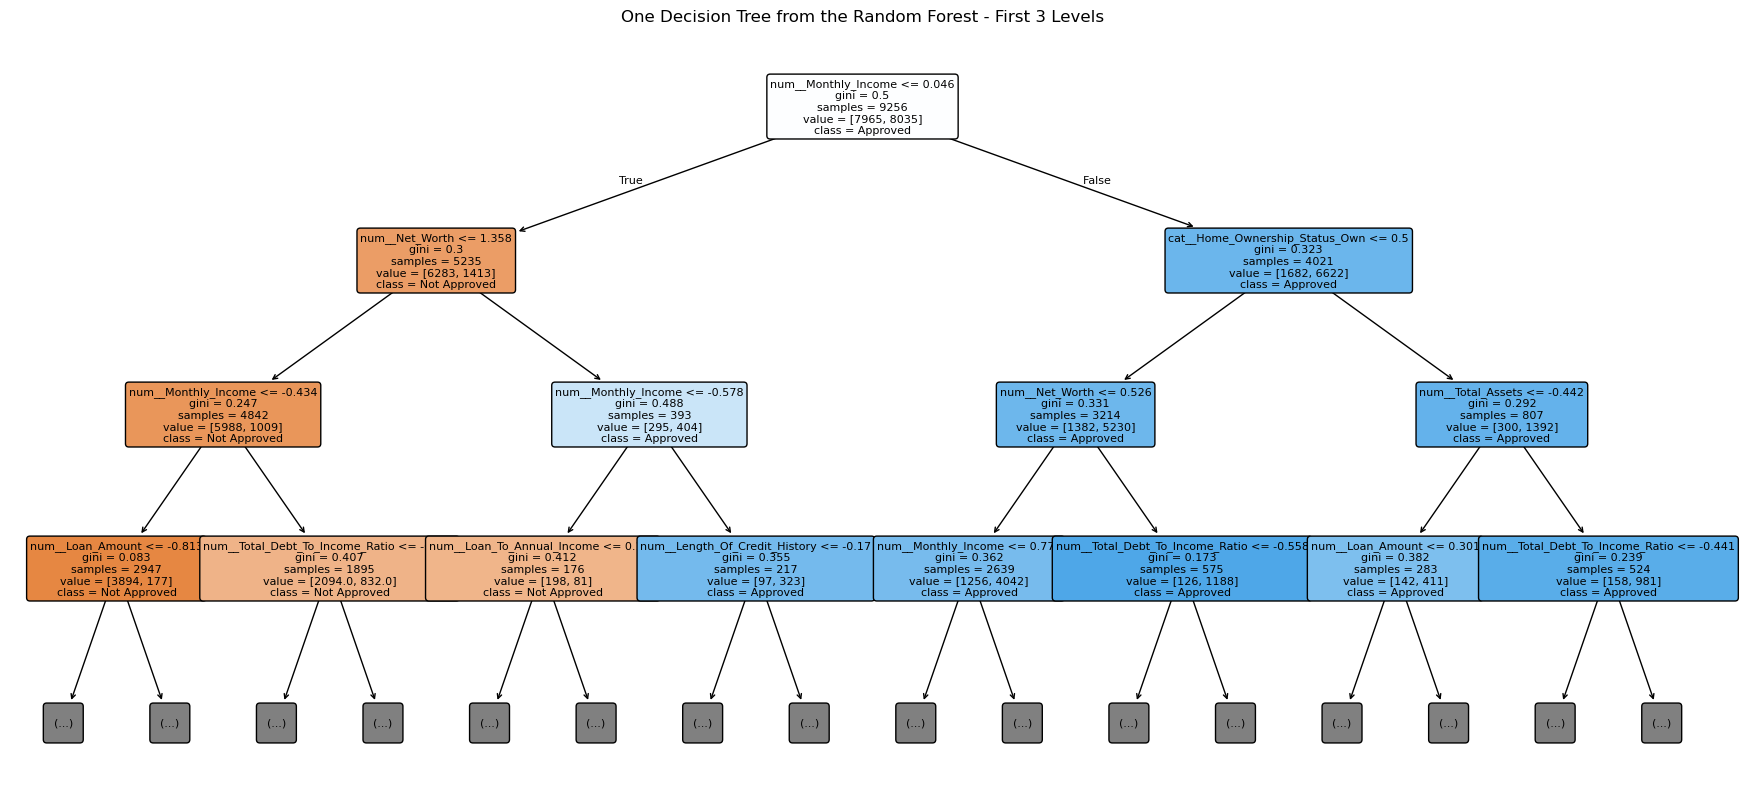

In [321]:
# Get the fitted preprocessing and Random Forest model

rf_prep = random_forest_pipeline.named_steps["preprocessing"]
rf_model_fitted = random_forest_pipeline.named_steps["model"]

rf_feature_names = rf_prep.get_feature_names_out()

# Select the first tree from the forest

one_tree = rf_model_fitted.estimators_[0]

# Draw one tree from the Random Forest

plt.figure(figsize=(22, 10))

plot_tree(
    one_tree,
    feature_names=rf_feature_names,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("One Decision Tree from the Random Forest - First 3 Levels")
plt.show()

## Hyperparameter Tuning

I will tune the Random Forest and Logistic regression using GridSearchCV, then pick a final model based on both performance and interpretability.

I chose Random Forest for tuning because it is an ensemble model that is relatively interpretable through feature importance and individual tree visualization.

I will test:
- number of trees
- maximum depth
- minimum samples per leaf

The tuning uses 5-fold stratified cross-validation and ROC-AUC.

# Tuned Logistic regression

In [322]:
# Create the Logistic Regression model

logreg_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Create the Logistic Regression pipeline

logreg_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", logreg_model)
])

# Choose different values to test

logreg_param_grid = {
    "preprocessing__num__imputer__strategy": ["median", "mean"],
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__class_weight": [None, "balanced"]
}

In [323]:
# Use GridSearchCV to find the best parameters

logreg_grid = GridSearchCV(
    logreg_pipeline,
    logreg_param_grid,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1,
    return_train_score=True
)

# Train the model

logreg_grid.fit(X_train, y_train)

# Show the best parameters

print("Best parameters:")
print(logreg_grid.best_params_)

Best parameters:
{'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2', 'preprocessing__num__imputer__strategy': 'mean'}


# Tuned Random Forest

In [325]:
# Create the Random Forest model for tuning

rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Create the Random Forest pipeline

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_model)
])

In [326]:
# Choose different values to test

rf_param_grid = {
    "model__n_estimators": [60, 100],
    "model__max_depth": [8, 12],
    "model__min_samples_leaf": [5, 10]
}

# Use GridSearchCV to find the best parameters

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1,
    return_train_score=True
)

# Train the model and test the different parameter combinations

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [8, 12], 'model__min_samples_leaf': [5, 10], 'model__n_estimators': [60, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``re

This defines the Random Forest hyperparameter search: 60 or 100 trees, maximum depth 8 or 12, and minimum leaf size 5 or 10. GridSearchCV evaluates the combinations using 5-fold stratified cross-validation and ROC-AUC as the selection metric.

In [327]:
# Show the best parameters

print("Best parameters:")
print(rf_grid.best_params_)

Best parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [328]:
# Show the best cross-validation ROC-AUC

print("Best mean CV ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Best mean CV ROC-AUC:
0.9631


The best mean cross-validation ROC-AUC is 0.9631. This indicates the selected Random Forest configuration separates the two historical approval classes extremely well in cross-validation.

In [329]:
# Display the tuning results

tuning_results = pd.DataFrame(rf_grid.cv_results_)

tuning_results = tuning_results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(tuning_results)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
5,100,12,5,0.963077,0.004629,1
4,60,12,5,0.962282,0.004523,2
7,100,12,10,0.962083,0.004332,3
6,60,12,10,0.961649,0.004275,4
1,100,8,5,0.959350,0.004365,5
3,100,8,10,0.959241,0.004547,6
0,60,8,5,0.959022,0.004258,7
2,60,8,10,0.958927,0.004761,8


This table records all tested Random Forest configurations, their mean ROC-AUC, variation and rank. The best row has 100 trees, depth 12 and leaf size 5, with mean ROC-AUC = 0.963. The results also show that increasing depth from 8 to 12 improved the tested configurations.


### CRISP-DM Summary: Modeling

- I used two regression models as classroom baselines and 8 classification models as the main approaches.

- The regression baselines were Simple Linear Regression and Multiple Linear Regression.

The classification models were ; Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting , SVM, KNN and XGBoost.

I evaluated the classification models using 5-fold stratified cross-validation and several metrics. I also tuned the Random Forest and logistic regression using GridSearchCV before final test-set evaluation.

## Evaluation and Conclusion


##  Evaluation

 I will evaluate the final tuned Random Forest  and logistic rgression on the held-out test data.

For classification I will check:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- ROC curve

For the regression baseline I will use a predicted versus actual scatter plot.I will also calculate the business cost proxy and check model performance across selected customer segments.

In [331]:
# Get the tuned Logistic Regression

logreg_model = logreg_grid.best_estimator_

logreg_pred = logreg_model.predict(X_test)
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]


# Get the tuned Random Forest

rf_model = rf_grid.best_estimator_

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [332]:
# Compare the two tuned models

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Tuned Logistic Regression": [
        accuracy_score(y_test, logreg_pred),
        precision_score(y_test, logreg_pred),
        recall_score(y_test, logreg_pred),
        f1_score(y_test, logreg_pred),
        roc_auc_score(y_test, logreg_prob)
    ],

    "Tuned Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_prob)
    ]
})

display(comparison.round(3))

,Metric,Tuned Logistic Regression,Tuned Random Forest
0,Accuracy,0.933,0.894
1,Precision,0.875,0.725
2,Recall,0.839,0.899
3,F1,0.856,0.802
4,ROC-AUC,0.979,0.965


In [334]:
# Select the final model

final_model = logreg_grid.best_estimator_

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("Final model selected: tuned Logistic Regression")

Final model selected: tuned Logistic Regression


Based on ROC-AUC, I  select the tuned Logistic Regression  as the final model, with a test ROC-AUC of 0.979 compared with 0.965 for the tuned Random Forest.

In [335]:
# Classification report for tuned Logistic Regression

print("Tuned Logistic Regression")
print(classification_report(y_test, logreg_pred, digits=3))


# Classification report for tuned Random Forest

print("Tuned Random Forest")
print(classification_report(y_test, rf_pred, digits=3))

Tuned Logistic Regression
              precision    recall  f1-score   support

           0      0.950     0.962     0.956      3044
           1      0.875     0.839     0.856       956

    accuracy                          0.933      4000
   macro avg      0.912     0.901     0.906      4000
weighted avg      0.932     0.933     0.932      4000

Tuned Random Forest
              precision    recall  f1-score   support

           0      0.966     0.893     0.928      3044
           1      0.725     0.899     0.802       956

    accuracy                          0.894      4000
   macro avg      0.845     0.896     0.865      4000
weighted avg      0.908     0.894     0.898      4000



The classification report separates performance by class.


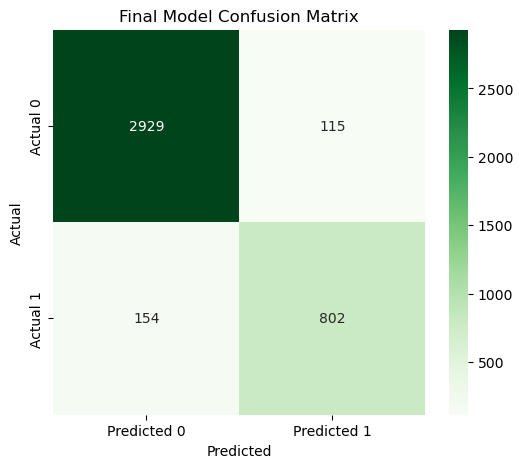

True Negative: 2929
False Positive: 115
False Negative: 154
True Positive: 802


In [336]:
#  Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)


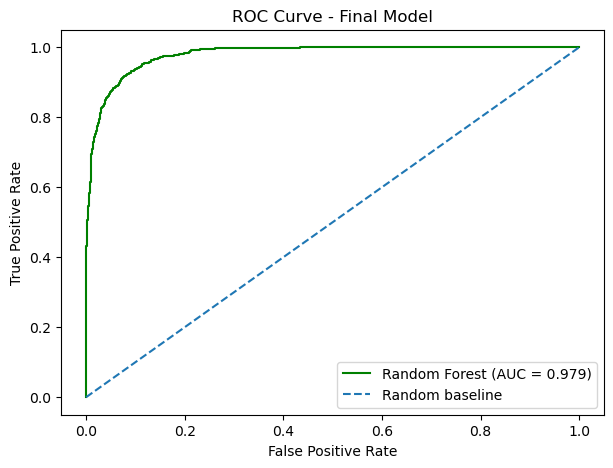

In [337]:
#  ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color="green",
    label=f"Random Forest (AUC = {auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()


This plots the ROC curve for the final Random Forest and reports an AUC of about 0.979. 

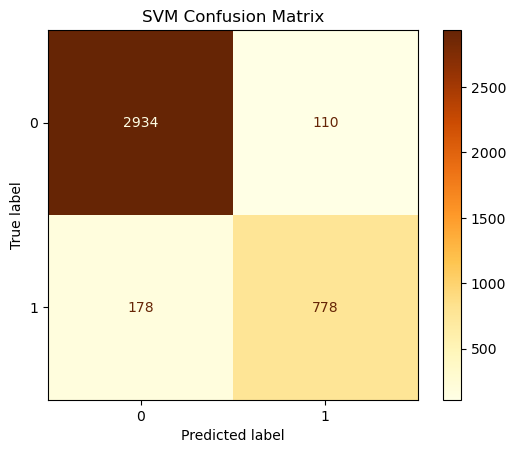

In [338]:
# SVM — Confusion Matrix

# Make predictions
svm_pred = svm_pipeline.predict(X_test)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap="YlOrBr"
)

plt.title("SVM Confusion Matrix")
plt.show()

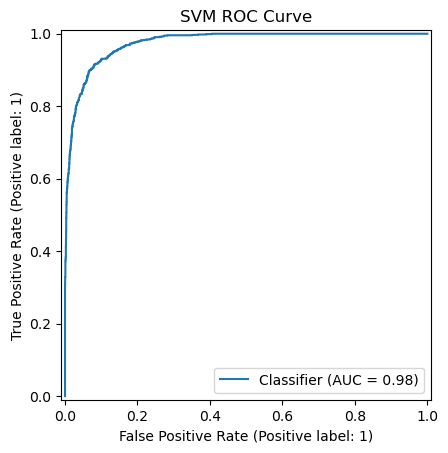

In [339]:
# Get predicted probabilities
svm_prob = svm_pipeline.predict_proba(X_test)[:, 1]

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    svm_prob,
    
)

plt.title("SVM ROC Curve")
plt.show()

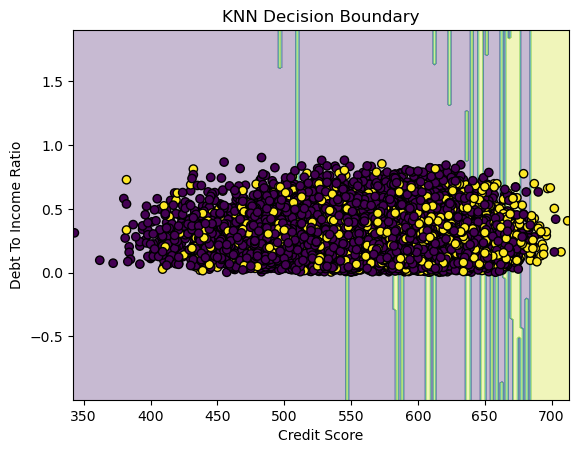

In [340]:


# Choose two features
features = ["Credit_Score", "Debt_To_Income_Ratio"]

X_2d = X_train[features]
y_2d = y_train

# Create KNN model
knn_2d = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_2d.fit(X_2d, y_2d)

# Create the grid
x_min = X_2d.iloc[:, 0].min() - 1
x_max = X_2d.iloc[:, 0].max() + 1

y_min = X_2d.iloc[:, 1].min() - 1
y_max = X_2d.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict for every point in the grid
Z = knn_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot the actual data points
plt.scatter(
    X_2d.iloc[:, 0],
    X_2d.iloc[:, 1],
    c=y_2d,
    edgecolor="black"
)

plt.xlabel("Credit Score")
plt.ylabel("Debt To Income Ratio")
plt.title("KNN Decision Boundary")
plt.show()

This creates a two feature KNN model using Credit_Score and Debt_To_Income_Ratio then plots its decision boundary.

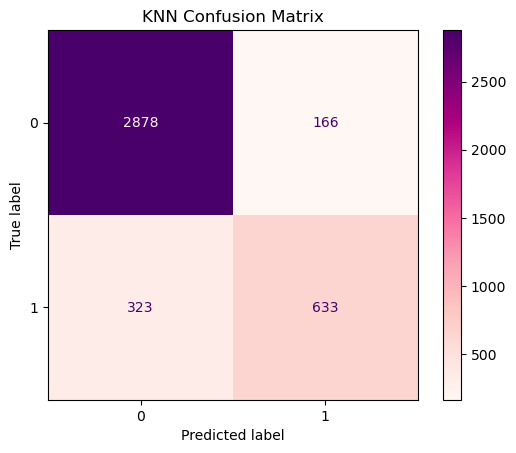

In [341]:
# Make predictions
knn_pred = knn_pipeline.predict(X_test)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    cmap="RdPu"
)

plt.title("KNN Confusion Matrix")
plt.show()

In [342]:
# Train the simple linear regression model

simple_regression.fit(
    X_train[["Credit_Score"]],
    y_train
)

# Train the multiple linear regression model

multiple_regression.fit(
    X_train[numeric_model_features],
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Age','Annual_Income','Credit_Score',...,'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio','Debt_To_Networth_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""

This fits the two regression baselines on the training data; simple regression using credit score and multiple regression using the numerical feature set. The returned Pipeline confirms median imputation, standardization and linear regression are connected in the model workflow.


In [343]:
# Make predictions using the simple model

simple_pred = simple_regression.predict(
    X_test[["Credit_Score"]]
)

# Make predictions using the multiple model

multiple_pred = multiple_regression.predict(
    X_test[numeric_model_features]
)

# Calculate metrics for the simple model

simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = mean_squared_error(y_test, simple_pred) ** 0.5
simple_r2 = r2_score(y_test, simple_pred)

print("Simple Linear Regression")
print("MAE:", round(simple_mae, 3))
print("RMSE:", round(simple_rmse, 3))
print("R2:", round(simple_r2, 3))


Simple Linear Regression
MAE: 0.357
RMSE: 0.422
R2: 0.02


On the data set ,test set, Simple Linear Regression gives MAE = 0.357, RMSE = 0.422 and R² = 0.020. This confirms that a single credit-score feature is not sufficient to explain the binary approval target well when treated as a continuous regression problem.


In [344]:
# Calculate metrics for the multiple model

multiple_mae = mean_absolute_error(y_test, multiple_pred)
multiple_rmse = mean_squared_error(y_test, multiple_pred) ** 0.5
multiple_r2 = r2_score(y_test, multiple_pred)

print("Multiple Linear Regression")
print("MAE:", round(multiple_mae, 3))
print("RMSE:", round(multiple_rmse, 3))
print("R2:", round(multiple_r2, 3))

Multiple Linear Regression
MAE: 0.229
RMSE: 0.301
R2: 0.503


Multiple Linear Regression gives test MAE = 0.229, RMSE = 0.301 and R² = 0.503. It improves over the simple regression baseline, but it remains a regression approximation.

In [345]:
# Compare both regression models

regression_results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        simple_mae,
        multiple_mae
    ],
    "RMSE": [
        simple_rmse,
        multiple_rmse
    ],
    "R2": [
        simple_r2,
        multiple_r2
    ]
})

display(regression_results.round(3))

,Model,MAE,RMSE,R2
0,Simple Linear Regression,0.357,0.422,0.020
1,Multiple Linear Regression,0.229,0.301,0.503


The regression table compares the two baseline regression models on the held out test data. Lower MAE and RMSE are better, while a higher R² means more variation in the binary target is explained.

These models are useful as baselines, but they are not the main solution because a binary approval decision is better treated as a classification problem.though multiple linear regression is better than a simple linear regression because it has a higher R2 of 0.503

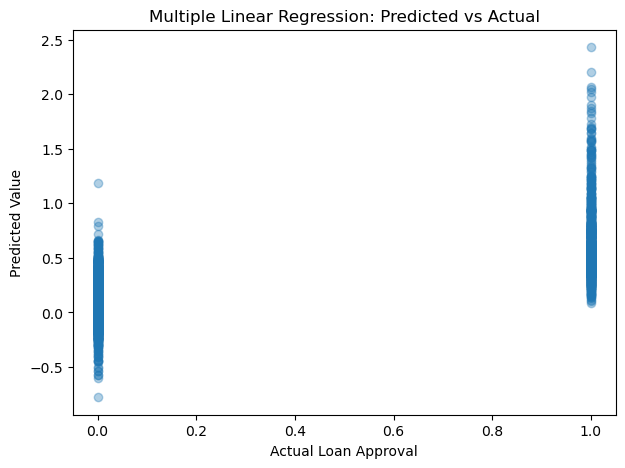

In [347]:
# Predicted versus actual values for Multiple Linear Regression

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    multiple_pred,
    alpha=0.35
)

plt.xlabel("Actual Loan Approval")
plt.ylabel("Predicted Value")
plt.title("Multiple Linear Regression: Predicted vs Actual")

plt.show()

In [348]:
# Calculate the business-cost proxy

# Set the cost of each type of mistake

FP_COST = 50000
FN_COST = 8000

# Calculate the cost of the final model

business_cost = (fp * FP_COST) + (fn * FN_COST)

# Calculate the cost if we always deny

always_deny_cost = int(y_test.sum()) * FN_COST

print("Always deny cost:", always_deny_cost)

# Calculate the cost if we always approve

always_approve_cost = int((y_test == 0).sum()) * FP_COST

print("Final model cost:", business_cost)
print("Always deny cost:", always_deny_cost)
print("Always approve cost:", always_approve_cost)

Always deny cost: 7648000
Final model cost: 6982000
Always deny cost: 7648000
Always approve cost: 152200000


The final model has an estimated business cost of 6,982,000, compared with 7,648,000 for always denying applications and 152,200,000 for always approving applications. Based on the assumed costs of false positives and false negatives, the final model has a lower estimated cost than both baseline strategies.

In [350]:
# Compare the three scenarios

cost_summary = pd.DataFrame({
    "Scenario": [
        "Final model",
        "Always deny",
        "Always approve"
    ],

    "False Positives": [
        fp,
        0,
        int((y_test == 0).sum())
    ],

    "False Negatives": [
        fn,
        int((y_test == 1).sum()),
        0
    ],

    "Proxy Cost ($)": [
        business_cost,
        always_deny_cost,
        always_approve_cost
    ]
})

display(cost_summary)

,Scenario,False Positives,False Negatives,Proxy Cost ($)
0,Final model,115,154,6982000
1,Always deny,0,956,7648000
2,Always approve,3044,0,152200000


In [352]:
# Check performance across selected customer segments
# Copy the test data

test_eval = X_test.copy()

test_eval["actual"] = y_test.values
test_eval["predicted"] = y_pred

# Divide customers into four income groups

test_eval["income_segment"] = pd.qcut(
    test_eval["Annual_Income"],
    q=4,
    duplicates="drop"
)

print(test_eval["income_segment"].value_counts())

income_segment
(14999.999, 30983.5]    1000
(30983.5, 47924.5]      1000
(47924.5, 73841.0]      1000
(73841.0, 300000.0]     1000
Name: count, dtype: int64


This creates four equally sized annual_income segments in the 4,000-row test set. Each segment contains 1,000 applications. The purpose is to check whether model performance changes across income levels.


In [353]:
# Divide customers into credit score groups

test_eval["credit_segment"] = pd.cut(
    test_eval["Credit_Score"],
    bins=[0, 579, 669, np.inf],
    labels=["Lower", "Middle", "Higher"]
)

print(test_eval["credit_segment"].value_counts())

# Create a list to store the results

segment_rows = []

credit_segment
Lower     2021
Middle    1955
Higher      24
Name: count, dtype: int64


The test data contains 2,021 customers  in the Lower credit_score group, 1,955 in the Middle group, and only 24 in the Higher group. This shows that the data is mainly concentrated in the Lower and Middle credit_score groups, while the Higher group has very few customers.

In [354]:
 # Calculate model performance for each customer segment

for column in ["Employment_Status", "income_segment", "credit_segment"]:

    for group, data in test_eval.groupby(column, observed=False):

        if len(data) >= 30:

            accuracy = accuracy_score(
                data["actual"],
                data["predicted"]
            )

            precision = precision_score(
                data["actual"],
                data["predicted"],
                zero_division=0
            )

            recall = recall_score(
                data["actual"],
                data["predicted"],
                zero_division=0
            )

            segment_rows.append([
                column,
                str(group),
                len(data),
                accuracy,
                precision,
                recall
            ])

In [355]:
# Put the results into a DataFrame

segment_results = pd.DataFrame(
    segment_rows,
    columns=[
        "Segment Variable",
        "Segment",
        "Number of Applications",
        "Accuracy",
        "Precision",
        "Recall"
    ]
)

display(segment_results.round(3))

,Segment Variable,Segment,Number of Applications,Accuracy,Precision,Recall
0,Employment_Status,Employed,3402,0.936,0.881,0.850
1,Employment_Status,Self-Employed,311,0.897,0.838,0.756
2,Employment_Status,Unemployed,287,0.937,0.833,0.800
3,income_segment,"(14999.999, 30983.5]",1000,0.992,0.800,0.571
4,income_segment,"(30983.5, 47924.5]",1000,0.963,0.807,0.639
5,income_segment,"(47924.5, 73841.0]",1000,0.893,0.797,0.709
6,income_segment,"(73841.0, 300000.0]",1000,0.883,0.906,0.913
7,credit_segment,Lower,2021,0.937,0.870,0.795
8,credit_segment,Middle,1955,0.929,0.879,0.868


This is a useful check for fairness .Performance is broadly consistent across income and credit_score segments. 

In [356]:
# Get the preprocessing and Logistic Regression model

prep = final_model.named_steps["preprocessing"]
model = final_model.named_steps["model"]

# Get feature names

feature_names = prep.get_feature_names_out()

# Get Logistic Regression coefficients

importance_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

# Sort by absolute coefficient

importance_table["Absolute Coefficient"] = (
    importance_table["Coefficient"].abs()
)

importance_table = importance_table.sort_values(
    "Absolute Coefficient",
    ascending=False
)

display(importance_table.head(15))

,Feature,Coefficient,Absolute Coefficient
23,num__Total_Debt_To_Income_Ratio,-6.150916,6.150916
44,cat__Bankruptcy_History_Yes,-3.345102,3.345102
19,num__Monthly_Income,2.390885,2.390885
29,cat__Employment_Status_Unemployed,-2.028346,2.028346
33,cat__Education_Level_High School,-1.975177,1.975177
22,num__Net_Worth,1.801809,1.801809
4,num__Loan_Amount,-1.617863,1.617863
5,num__Loan_Duration,-1.583792,1.583792
30,cat__Education_Level_Associate,-1.246136,1.246136
38,cat__Marital_Status_Widowed,-1.077515,1.077515


This shows the Logistic Regression coefficients and sorts the features by their influence on loan approval.
Total_Debt_to_Income Ratio and Bankruptcy History have the strongest influence in this model.

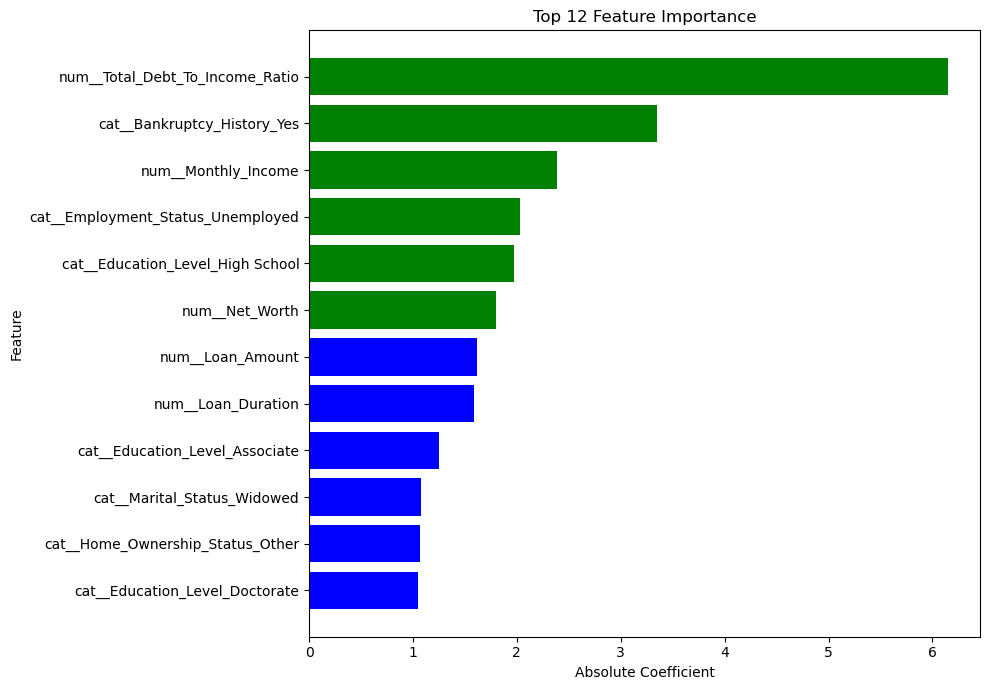

In [357]:
# Top feature importance

top_features = importance_table.head(12).sort_values(
    "Absolute Coefficient"
)

# Set colors
colors = []

for value in top_features["Absolute Coefficient"]:
    if value >= top_features["Absolute Coefficient"].median():
        colors.append("green")
    else:
        colors.append("blue")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Absolute Coefficient"],
    color=colors
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 12 Feature Importance")

plt.tight_layout()
plt.show()

This shows that the model gives strong importance to the Total_Debt-to-Income_Ratio when making loan approval predictions.

1. Business Understanding

The main objective of this project is to help loan officers make a consistent first stage assessment when reviewing loan applications.

The project considered the following business costs:

- False approval: $50,000
- False denial: $8,000

Since the cost of a false approval is much higher than the cost of a false denial, accuracy alone is not enough to evaluate the models. I therefore considered several evaluation measures:

- Precision
- Recall
- F1-score
- Cost-sensitive measure
- Accuracy

The target variable, Loan_Approved, is binary because an applicant is either approved or not approved.

Therefore:

I used Classification as the main modelling approach and Regression  as a classroom baseline.


2. Data Understanding

I first examined the dataset to understand its structure, quality, and target variable. The dataset contained:

- 20,000 rows
- 35 columns
- 0 duplicate rows
- 2,804 missing values

The target variable, Loan_Approved, was not evenly distributed:

- 15,220 not-approved cases (76.1%)
- 4,780 approved cases (23.9%)

This shows that the dataset has a class imbalance, with more applicants being not approved than approved.

To better understand the data, I also examined:

- Distributions of numerical variables
- Relationships between categorical variables and the target
- Correlations between numerical variables
- Pairwise relationships between variables
- Statistical associations between variables

This analysis helped me understand the main patterns in the data and identify issues that needed to be considered during preprocessing and modelling.


3. Data Preparation

In this stage, I prepared the data for modelling by cleaning the variables and setting up the preprocessing steps.

The main steps were:

- Cleaned the Annual_Income variable.
- Separated the predictor variables (X) from the target variable (y).
- dropped variables that were causing data leakage
- Created three new financial ratios to provide additional information for the models.
- Split the data into 80% training data and 20% testing data using stratification to maintain the same class distribution.
- For numerical variables, I used median imputation to handle missing values and then applied scaling.
- For categorical variables, I filled missing values and used one-hot encoding to convert them into numerical form.
- I used a ColumnTransformer and Pipeline to keep the preprocessing steps organized and help prevent data leakage.

I also compared mean and median imputation using cross-validation. Their results were very similar, so I chose median imputation for the final workflow.

4. Modelling

In this stage, I tested different machine learning models to find out which ones could best predict loan approval.

The models I tested were:

- 2 regression models as baseline models
- 8 classification models for the main prediction task

The classification models performed strongly during cross-validation.

I selected Random Forest and Logistic Regression  for further tuning because:

- It can capture non-linear relationships in the data.
- It provides feature importance, which helps me understand which variables are important for the prediction.

After comparing the models,I used Random Forest and Logistic Regression  for further tuning and evaluation.


5. Evaluation

I selected the tuned Logistic Regression  because it is easier to understand than the Random Forest.It performed well on the test data and had a lower estimated business cost than the other strategies.Its performance was fairly consistent across different customer groups.The important features, such as debt-to-income ratio, income, and credit history, also make sense for loan approval.

7. Main Limitation

The model predicts past loan approval decisions, not actual loan defaults.The $8,000 and $50,000 costs are estimates used in this project.The model should be tested with real loan default data before being used.It should also be checked for fairness and possible bias.

## OUTCOME
The tuned Logistic Regression model is  the best performing model in my study, achieving 93.3% accuracy, preession = 87.5% , recall = 83.9% ,  F1-score, = 95.6% and 97.9% ROC-AUC on the test set.